# Exploratory Data Analysis and Preprocessing for Music Genre Classification

**Dataset:** `features_3_sec`  
**Domain:** Audio feature extraction / Music genre classification  
**Task:** Multiclass classification (10 music genres)  
**Target column:** `label`  
**Identifier column:** `filename`

This notebook performs exploratory data analysis (EDA), statistical analysis, data visualization, data quality checks, and preprocessing. **No machine learning models are trained here.** Subsequent notebooks will cover Linear Classifier, Random Forest, and Neural Network models.


## PART 1 — Setup and Data Loading


### Cell 1 — Import Libraries


In [2]:
# Core data manipulation and numerical computing
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats

# Scikit-learn: preprocessing and splitting (no model training in this notebook)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Reproducibility and plot style
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")
sns.set_palette("husl")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

print("Libraries imported successfully.")
print(f"Random state for reproducibility: {RANDOM_STATE}")


Libraries imported successfully.
Random state for reproducibility: 42


### Cell 2 — Load Dataset


In [ ]:
# Exact dataset path
DATA_PATH = r"path"

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Keep an immutable reference to the original loaded data
df_original = df.copy()

print("Dataset loaded successfully.")
print(f"File path: {DATA_PATH}")


### Cell 3 — Initial Display of Dataset Structure


In [4]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
display(df.tail())

print("\n" + "=" * 60)
print("RANDOM 5 ROWS (random_state=42)")
print("=" * 60)
display(df.sample(5, random_state=RANDOM_STATE))

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(list(df.columns))

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
display(df.dtypes.to_frame(name="dtype"))

print("\n" + "=" * 60)
print("MEMORY USAGE")
print("=" * 60)
mem = df.memory_usage(deep=True)
print(f"Total memory usage: {mem.sum() / 1024**2:.2f} MB")
display(mem.to_frame(name="bytes"))

print("\n" + "=" * 60)
print("DATAFRAME INFO")
print("=" * 60)
df.info()


DATASET SHAPE
Rows: 9,990 | Columns: 60

FIRST 5 ROWS


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues



LAST 5 ROWS


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
9985,rock.00099.5.wav,66149,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,rock
9986,rock.00099.6.wav,66149,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,rock
9987,rock.00099.7.wav,66149,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,rock
9988,rock.00099.8.wav,66149,0.387527,0.084815,0.066430,0.000320,2084.515327,203891.039161,2018.366254,22860.992562,...,28.323744,-5.363541,17.209942,6.462601,21.442928,2.354765,24.843613,0.675824,12.787750,rock
9989,rock.00099.9.wav,66149,0.369293,0.086759,0.050524,0.000067,1634.330126,411429.169769,1867.422378,119722.211518,...,38.801735,-11.598399,58.983097,-0.178517,55.761299,-6.903252,39.485901,-3.412534,31.727489,rock



RANDOM 5 ROWS (random_state=42)


...


COLUMN NAMES
['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']

DATA TYPES


,dtype
filename,object
length,int64
chroma_stft_mean,float64
chroma_stft_var,float64
rms_mean,float64
rms_var,float64
spectral_centroid_mean,float64
spectral_centroid_var,float64
spectral_bandwidth_mean,float64
spectral_bandwidth_var,float64



MEMORY USAGE
Total memory usage: 5.57 MB


,bytes
Index,132
filename,663326
length,79920
chroma_stft_mean,79920
chroma_stft_var,79920
...,...
mfcc19_mean,79920
mfcc19_var,79920
mfcc20_mean,79920
mfcc20_var,79920



DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harmony_

### Cell 4 — Dataset Structure Explanation


### Dataset structure

| Role | Column(s) | Description |
|------|-----------|-------------|
| **Identifier** | `filename` | Unique name of the audio segment file; not used as a predictive feature |
| **Target** | `label` | Music genre class (multiclass, 10 genres) |
| **Features** | All other numeric columns | Audio descriptors extracted from ~3-second music segments |

**Task:** Multiclass music genre classification — predict `label` from audio features.

Expected feature groups include chroma, RMS energy, spectral descriptors, zero-crossing rate, harmony/perceptual features, tempo, and MFCC coefficients (mean and variance).


### Cell 5 — Complete List of Columns


In [5]:
print("Complete column list ({0} columns):".format(len(df.columns)))
for i, col in enumerate(df.columns, start=1):
    print(f"{i:2d}. {col}")


Complete column list (60 columns):
 1. filename
 2. length
 3. chroma_stft_mean
 4. chroma_stft_var
 5. rms_mean
 6. rms_var
 7. spectral_centroid_mean
 8. spectral_centroid_var
 9. spectral_bandwidth_mean
10. spectral_bandwidth_var
11. rolloff_mean
12. rolloff_var
13. zero_crossing_rate_mean
14. zero_crossing_rate_var
15. harmony_mean
16. harmony_var
17. perceptr_mean
18. perceptr_var
19. tempo
20. mfcc1_mean
21. mfcc1_var
22. mfcc2_mean
23. mfcc2_var
24. mfcc3_mean
25. mfcc3_var
26. mfcc4_mean
27. mfcc4_var
28. mfcc5_mean
29. mfcc5_var
30. mfcc6_mean
31. mfcc6_var
32. mfcc7_mean
33. mfcc7_var
34. mfcc8_mean
35. mfcc8_var
36. mfcc9_mean
37. mfcc9_var
38. mfcc10_mean
39. mfcc10_var
40. mfcc11_mean
41. mfcc11_var
42. mfcc12_mean
43. mfcc12_var
44. mfcc13_mean
45. mfcc13_var
46. mfcc14_mean
47. mfcc14_var
48. mfcc15_mean
49. mfcc15_var
50. mfcc16_mean
51. mfcc16_var
52. mfcc17_mean
53. mfcc17_var
54. mfcc18_mean
55. mfcc18_var
56. mfcc19_mean
57. mfcc19_var
58. mfcc20_mean
59. mfcc20_var

## PART 2 — Initial Dataset Understanding


### Cell 6 — Basic Dataset Questions


In [6]:
# 1. Rows and columns
print(f"1. Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")

# 2. Column names
print(f"\n2. Column names ({len(df.columns)} total):")
print(list(df.columns))

# 3. Target variable
TARGET_COL = "label"
print(f"\n3. Target variable: '{TARGET_COL}'")

# 4. Input features (exclude identifier and target)
ID_COL = "filename"
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET_COL]]
print(f"\n4. Input features ({len(feature_cols)} columns):")
print(feature_cols[:10], "...")

# 5. Identifier column
print(f"\n5. Identifier column (non-predictive): '{ID_COL}'")

# 6. Numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n6. Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)

# 7. Categorical columns (object/category)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"\n7. Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)


1. Dataset dimensions: 9990 rows × 60 columns

2. Column names (60 total):
['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']

3. Targ

### Cell 7 — Unique Values per Column


In [7]:
unique_counts = df.nunique().sort_values(ascending=False)
print("Number of unique values per column:")
display(unique_counts.to_frame(name="n_unique"))

# Categorical: label
print("\nUnique values in 'label':")
print(sorted(df["label"].unique()))
print(f"\nNumber of genre classes: {df['label'].nunique()}")

# Class names
print("\nTarget class names:")
for genre in sorted(df["label"].unique()):
    print(f"  - {genre}")


Number of unique values per column:


,n_unique
filename,9990
spectral_bandwidth_var,9847
spectral_centroid_mean,9847
spectral_centroid_var,9847
rolloff_var,9847
spectral_bandwidth_mean,9847
harmony_mean,9847
harmony_var,9847
mfcc3_mean,9847
perceptr_mean,9847



Unique values in 'label':
['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Number of genre classes: 10

Target class names:
  - blues
  - classical
  - country
  - disco
  - hiphop
  - jazz
  - metal
  - pop
  - reggae
  - rock


### Cell 8 — Samples per Music Genre


In [8]:
class_counts = df["label"].value_counts().sort_index()
print("Number of samples per music genre:")
display(class_counts.to_frame(name="count"))

# Explicit role identification
print("\n--- Column roles ---")
print("Target column: 'label'")
print("Identifier column: 'filename' (exclude from modeling)")
print(f"'length' unique values: {df['length'].nunique()} — check for constant/near-constant behavior")


Number of samples per music genre:


,count
label,
blues,1000
classical,998
country,997
disco,999
hiphop,998
jazz,1000
metal,1000
pop,1000
reggae,1000



--- Column roles ---
Target column: 'label'
Identifier column: 'filename' (exclude from modeling)
'length' unique values: 1 — check for constant/near-constant behavior


### Cell 9 — Comprehensive Summary Table


In [9]:
def build_summary_table(dataframe):
    """Build an academic summary table for all columns."""
    rows = []
    for col in dataframe.columns:
        series = dataframe[col]
        row = {
            "column": col,
            "dtype": str(series.dtype),
            "n_unique": series.nunique(),
            "n_missing": series.isna().sum(),
            "missing_pct": 100 * series.isna().mean(),
        }
        if pd.api.types.is_numeric_dtype(series):
            row.update({
                "min": series.min(),
                "max": series.max(),
                "mean": series.mean(),
                "median": series.median(),
                "std": series.std(),
            })
        else:
            row.update({"min": np.nan, "max": np.nan, "mean": np.nan,
                        "median": np.nan, "std": np.nan})
        rows.append(row)
    return pd.DataFrame(rows)

summary_table = build_summary_table(df)
print("Comprehensive column summary:")
display(summary_table.round(4))


Comprehensive column summary:


,column,dtype,n_unique,n_missing,missing_pct,min,max,mean,median,std
0,filename,object,9990,0,0.0,NaN,NaN,NaN,NaN,NaN
1,length,int64,1,0,0.0,66149.0000,6.614900e+04,6.614900e+04,6.614900e+04,0.000000e+00
2,chroma_stft_mean,float64,9845,0,0.0,0.1071,7.495000e-01,3.795000e-01,3.847000e-01,9.050000e-02
3,chroma_stft_var,float64,9831,0,0.0,0.0153,1.210000e-01,8.490000e-02,8.510000e-02,9.600000e-03
4,rms_mean,float64,9846,0,0.0,0.0010,4.426000e-01,1.309000e-01,1.213000e-01,6.850000e-02
5,rms_var,float64,9846,0,0.0,0.0000,3.260000e-02,2.700000e-03,1.500000e-03,3.600000e-03
6,spectral_centroid_mean,float64,9847,0,0.0,472.7416,5.432534e+03,2.199219e+03,2.208628e+03,7.518606e+02
7,spectral_centroid_var,float64,9847,0,0.0,811.8813,4.794119e+06,4.166727e+05,2.650692e+05,4.349644e+05
8,spectral_bandwidth_mean,float64,9847,0,0.0,499.1629,3.708148e+03,2.241386e+03,2.230576e+03,5.438544e+02
9,spectral_bandwidth_var,float64,9847,0,0.0,1183.5203,1.235143e+06,1.182711e+05,8.996072e+04,1.013505e+05


## PART 3 — Missing Values and Data Quality Checks


**Note:** The original dataframe `df` is preserved. Cleaned versions are stored in separate variables (e.g., `df_clean`).


### Cell 10 — Missing Values Analysis


In [10]:
missing_count = df.isnull().sum()
missing_pct = 100 * df.isnull().mean()

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": missing_pct.round(4)
}).sort_values("missing_count", ascending=False)

print("Missing values per column:")
display(missing_df)

if missing_count.sum() == 0:
    print("\n✓ No missing values were found in any column.")
else:
    print(f"\nTotal missing cells: {missing_count.sum()}")


Missing values per column:


,missing_count,missing_percentage
filename,0,0.0
length,0,0.0
chroma_stft_mean,0,0.0
chroma_stft_var,0,0.0
rms_mean,0,0.0
rms_var,0,0.0
spectral_centroid_mean,0,0.0
spectral_centroid_var,0,0.0
spectral_bandwidth_mean,0,0.0
spectral_bandwidth_var,0,0.0



✓ No missing values were found in any column.


### Cell 11 — Missing Values Heatmap


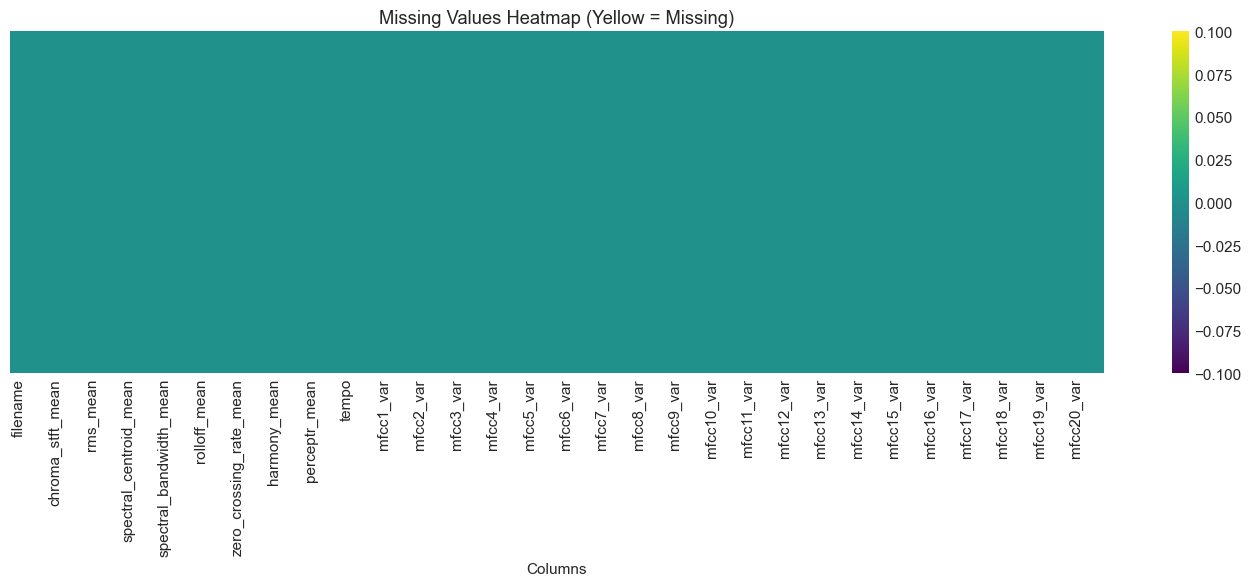

Heatmap confirms: no missing values in the dataset.


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Values Heatmap (Yellow = Missing)")
ax.set_xlabel("Columns")
plt.tight_layout()
plt.show()

if df.isnull().sum().sum() == 0:
    print("Heatmap confirms: no missing values in the dataset.")


### Cell 12 — Duplicate Row Analysis


In [12]:
n_duplicates = df.duplicated().sum()
pct_duplicates = 100 * n_duplicates / len(df)

print(f"Duplicate rows (exact match on all columns): {n_duplicates}")
print(f"Percentage of duplicate rows: {pct_duplicates:.4f}%")

# Duplicated filenames
dup_filenames = df["filename"].duplicated().sum()
print(f"\nDuplicated filenames: {dup_filenames}")

# Duplicated feature rows (excluding filename)
feature_only_cols = [c for c in df.columns if c != "filename"]
dup_features = df.duplicated(subset=feature_only_cols).sum()
print(f"Duplicated feature rows (excluding filename): {dup_features}")


Duplicate rows (exact match on all columns): 0
Percentage of duplicate rows: 0.0000%

Duplicated filenames: 0
Duplicated feature rows (excluding filename): 133


### Cell 13 — Create df_clean (Remove Duplicates if Needed)


In [13]:
# Do not modify df directly — create df_clean
shape_before = df.shape
df_clean = df.drop_duplicates().copy()
shape_after = df_clean.shape

print(f"Shape before duplicate removal: {shape_before}")
print(f"Shape after duplicate removal:  {shape_after}")

if shape_before != shape_after:
    print(f"Removed {shape_before[0] - shape_after[0]} duplicate row(s).")
    print("Decision: Duplicates removed because exact duplicate rows add no information.")
else:
    print("No duplicate rows found. df_clean is identical in row count to df.")


Shape before duplicate removal: (9990, 60)
Shape after duplicate removal:  (9990, 60)
No duplicate rows found. df_clean is identical in row count to df.


### Cell 14 — Constant and Near-Constant Columns


In [14]:
def find_near_constant_columns(dataframe, threshold=0.99):
    """Columns where one value accounts for >= threshold of rows."""
    near_constant = []
    for col in dataframe.columns:
        top_freq = dataframe[col].value_counts(normalize=True).iloc[0]
        if top_freq >= threshold:
            near_constant.append((col, dataframe[col].nunique(), top_freq))
    return near_constant

near_const = find_near_constant_columns(df_clean)
print("Constant / near-constant columns (top value frequency >= 99%):")
if near_const:
    for col, n_unique, freq in near_const:
        print(f"  - {col}: n_unique={n_unique}, top_freq={freq:.4f}")
else:
    print("  None detected at 99% threshold.")

# Specific check for length
length_unique = df_clean["length"].nunique()
print(f"\n'length' column — number of unique values: {length_unique}")
if length_unique == 1:
    print("'length' is CONSTANT. It does not vary across samples and likely reflects")
    print("fixed segment duration (e.g., sample count). It should be dropped during preprocessing.")
elif length_unique <= 3:
    print("'length' has very low variance — review before modeling.")


Constant / near-constant columns (top value frequency >= 99%):
  - length: n_unique=1, top_freq=1.0000

'length' column — number of unique values: 1
'length' is CONSTANT. It does not vary across samples and likely reflects
fixed segment duration (e.g., sample count). It should be dropped during preprocessing.


### Cell 15 — Suspicious Value Checks


In [15]:
numeric_df = df_clean.select_dtypes(include=[np.number])

# Audio features are generally non-negative except some MFCC/harmony values
negative_cols = []
for col in numeric_df.columns:
    if col == "length":
        continue
    if (numeric_df[col] < 0).any() and "mfcc" not in col and "harmony" not in col and "perceptr" not in col:
        if numeric_df[col].min() < -1e-6:
            negative_cols.append((col, numeric_df[col].min()))

print("Columns with unexpected negative minima (excluding MFCC/harmony/perceptual):")
if negative_cols:
    for col, vmin in negative_cols:
        print(f"  {col}: min = {vmin}")
else:
    print("  No suspicious negative values in strictly non-negative audio descriptors.")

# Tempo sanity (typical range roughly 40–220 BPM for music)
if "tempo" in numeric_df.columns:
    t_min, t_max = numeric_df["tempo"].min(), numeric_df["tempo"].max()
    print(f"\nTempo range: [{t_min:.2f}, {t_max:.2f}] BPM")
    if t_min < 30 or t_max > 300:
        print("  Note: Some tempo values fall outside typical musical ranges — may be estimation artifacts.")

print("\n" + "=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)
print(f"Rows: {len(df_clean):,} | Columns: {df_clean.shape[1]}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows removed: {len(df) - len(df_clean)}")
print(f"Constant 'length' column: {df_clean['length'].nunique() == 1}")
print(f"Target classes: {df_clean['label'].nunique()}")
print("Overall: Dataset appears suitable for EDA and preprocessing.")


Columns with unexpected negative minima (excluding MFCC/harmony/perceptual):
  No suspicious negative values in strictly non-negative audio descriptors.

Tempo range: [24.38, 287.11] BPM
  Note: Some tempo values fall outside typical musical ranges — may be estimation artifacts.

DATA QUALITY REPORT
Rows: 9,990 | Columns: 60
Missing values: 0
Duplicate rows removed: 0
Constant 'length' column: True
Target classes: 10
Overall: Dataset appears suitable for EDA and preprocessing.


## PART 4 — Descriptive Statistics


### Cell 16 — Full Descriptive Statistics


In [16]:
print("Descriptive statistics (all columns where applicable):")
display(df_clean.describe(include="all").T)


Descriptive statistics (all columns where applicable):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
filename,9990,9990,rock.00099.9.wav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length,9990.0,NaN,NaN,NaN,66149.0,0.0,66149.0,66149.0,66149.0,66149.0,66149.0
chroma_stft_mean,9990.0,NaN,NaN,NaN,0.379534,0.090466,0.107108,0.315698,0.384741,0.442443,0.749481
chroma_stft_var,9990.0,NaN,NaN,NaN,0.084876,0.009637,0.015345,0.079833,0.085108,0.091092,0.120964
rms_mean,9990.0,NaN,NaN,NaN,0.130859,0.068545,0.000953,0.083782,0.121253,0.176328,0.442567
rms_var,9990.0,NaN,NaN,NaN,0.002676,0.003586,0.0,0.000615,0.001491,0.003131,0.032615
spectral_centroid_mean,9990.0,NaN,NaN,NaN,2199.219431,751.860611,472.741636,1630.680158,2208.628236,2712.581884,5432.534406
spectral_centroid_var,9990.0,NaN,NaN,NaN,416672.69895,434964.436258,811.881305,123196.130771,265069.214619,562415.249295,4794118.600272
spectral_bandwidth_mean,9990.0,NaN,NaN,NaN,2241.385959,543.854449,499.16291,1887.45579,2230.575595,2588.340505,3708.147554
spectral_bandwidth_var,9990.0,NaN,NaN,NaN,118271.112919,101350.463283,1183.520328,48765.526957,89960.719868,158567.35314,1235142.513157


### Cell 17 — Transposed Descriptive Statistics


In [17]:
desc_numeric = df_clean.describe().T
print("Transposed descriptive statistics (numeric columns):")
display(desc_numeric)


Transposed descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
length,9990.0,6.614900e+04,0.000000e+00,6.614900e+04,66149.000000,6.614900e+04,6.614900e+04,6.614900e+04
chroma_stft_mean,9990.0,3.795341e-01,9.046576e-02,1.071078e-01,0.315698,3.847409e-01,4.424433e-01,7.494808e-01
chroma_stft_var,9990.0,8.487615e-02,9.636622e-03,1.534475e-02,0.079833,8.510794e-02,9.109229e-02,1.209643e-01
rms_mean,9990.0,1.308591e-01,6.854539e-02,9.534877e-04,0.083782,1.212534e-01,1.763277e-01,4.425668e-01
rms_var,9990.0,2.676388e-03,3.585628e-03,4.379535e-08,0.000615,1.491318e-03,3.130862e-03,3.261522e-02
spectral_centroid_mean,9990.0,2.199219e+03,7.518606e+02,4.727416e+02,1630.680158,2.208628e+03,2.712582e+03,5.432534e+03
spectral_centroid_var,9990.0,4.166727e+05,4.349644e+05,8.118813e+02,123196.130771,2.650692e+05,5.624152e+05,4.794119e+06
spectral_bandwidth_mean,9990.0,2.241386e+03,5.438544e+02,4.991629e+02,1887.455790,2.230576e+03,2.588341e+03,3.708148e+03
spectral_bandwidth_var,9990.0,1.182711e+05,1.013505e+05,1.183520e+03,48765.526957,8.996072e+04,1.585674e+05,1.235143e+06
rolloff_mean,9990.0,4.566077e+03,1.642065e+03,6.583363e+02,3378.311110,4.631378e+03,5.591635e+03,9.487446e+03


### Cell 18 — Descriptive Statistics by Genre


In [18]:
# Grouped descriptive statistics for numerical features
numeric_feature_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
grouped_mean = df_clean.groupby("label")[numeric_feature_cols].mean()
print("Mean values of numerical features by music genre (first 10 features):")
display(grouped_mean.iloc[:, :10].round(4))


Mean values of numerical features by music genre (first 10 features):


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean
label,,,,,,,,,,
blues,66149.0,0.3424,0.0899,0.1360,0.0026,1726.0679,245598.2196,1930.8497,95125.6888,3632.9131
classical,66149.0,0.2645,0.0834,0.0428,0.0004,1351.3201,70830.2306,1519.5316,47788.7457,2475.8176
country,66149.0,0.3450,0.0854,0.1257,0.0014,1891.1876,328737.7613,2096.4073,127052.8952,3938.4716
disco,66149.0,0.4164,0.0834,0.1362,0.0027,2617.2850,466543.4850,2512.3558,125423.2523,5514.6483
hiphop,66149.0,0.4546,0.0868,0.1782,0.0067,2521.5184,703894.9642,2512.2845,153455.0687,5327.6905
jazz,66149.0,0.2975,0.0880,0.0866,0.0012,1790.2817,206724.0080,2019.7643,89887.7951,3744.7247
metal,66149.0,0.4802,0.0724,0.1535,0.0011,2600.8817,183577.3353,2242.8198,58359.3573,5123.7532
pop,66149.0,0.3981,0.0877,0.1996,0.0065,3069.9930,876099.9767,3006.8030,158980.6604,6647.6315
reggae,66149.0,0.4090,0.0893,0.1224,0.0029,2182.2136,708041.2991,2309.7967,207941.2212,4586.9383


### Cell 19 — Class Distribution and Balance


In [19]:
class_counts = df_clean["label"].value_counts().sort_index()
class_pct = (100 * class_counts / class_counts.sum()).round(2)

dist_table = pd.DataFrame({
    "genre": class_counts.index,
    "count": class_counts.values,
    "percentage": class_pct.values
})
print("Class distribution:")
display(dist_table)

# Balance assessment
ratio = class_counts.max() / class_counts.min()
print(f"\nMax/min class ratio: {ratio:.4f}")
if ratio <= 1.1:
    balance_msg = "The dataset is approximately BALANCED across genres."
elif ratio <= 1.5:
    balance_msg = "The dataset is moderately balanced with minor imbalance."
else:
    balance_msg = "The dataset shows noticeable class imbalance."
print(balance_msg)


Class distribution:


,genre,count,percentage
0,blues,1000,10.01
1,classical,998,9.99
2,country,997,9.98
3,disco,999,10.00
4,hiphop,998,9.99
5,jazz,1000,10.01
6,metal,1000,10.01
7,pop,1000,10.01
8,reggae,1000,10.01
9,rock,998,9.99



Max/min class ratio: 1.0030
The dataset is approximately BALANCED across genres.


### Cell 20 — Class Distribution Visualizations


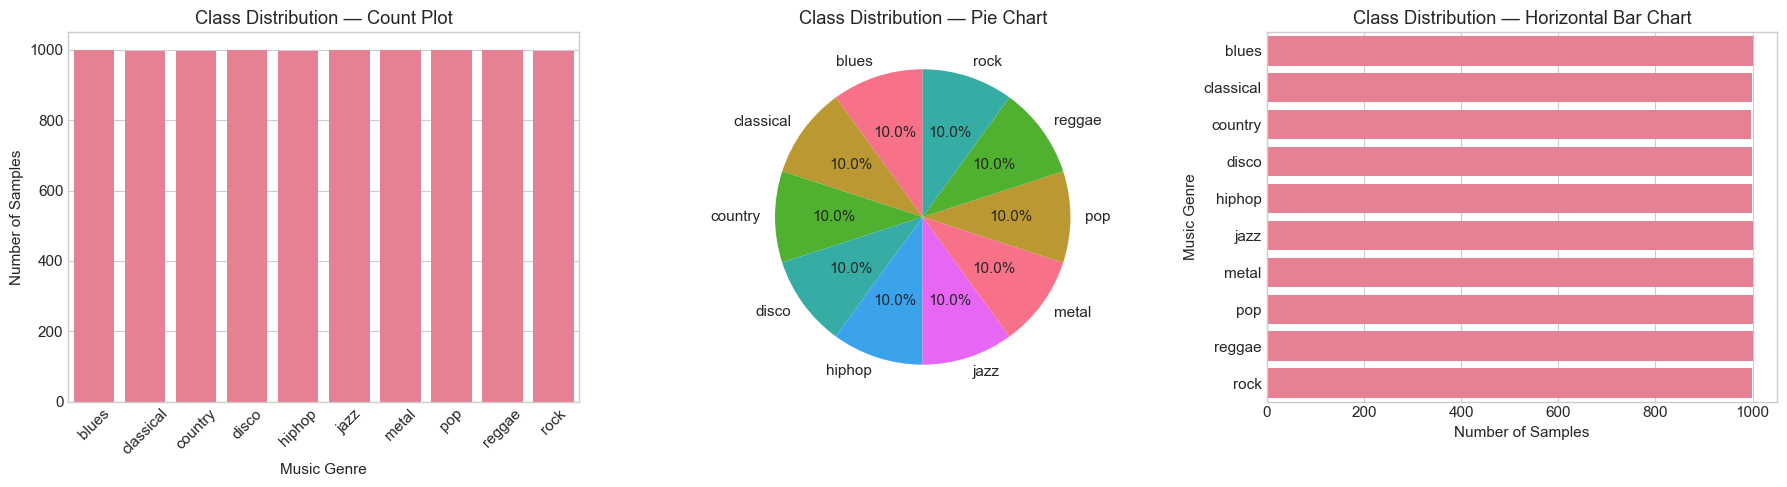

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count plot
order = sorted(df_clean["label"].unique())
sns.countplot(data=df_clean, x="label", order=order, ax=axes[0])
axes[0].set_title("Class Distribution — Count Plot")
axes[0].set_xlabel("Music Genre")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis="x", rotation=45)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Distribution — Pie Chart")

# Horizontal bar chart
sns.barplot(x=class_counts.values, y=class_counts.index, ax=axes[2], orient="h")
axes[2].set_title("Class Distribution — Horizontal Bar Chart")
axes[2].set_xlabel("Number of Samples")
axes[2].set_ylabel("Music Genre")

plt.tight_layout()
plt.show()


## PART 5 — Feature Distributions


### Audio feature groups (high-level)

| Group | Columns (examples) | Meaning |
|-------|-------------------|---------|
| **Chroma** | `chroma_stft_mean`, `chroma_stft_var` | Pitch class profile — harmonic content |
| **RMS** | `rms_mean`, `rms_var` | Root-mean-square energy — loudness |
| **Spectral centroid** | `spectral_centroid_mean/var` | Brightness of sound |
| **Spectral bandwidth** | `spectral_bandwidth_mean/var` | Frequency spread |
| **Spectral rolloff** | `rolloff_mean/var` | Frequency below which most energy is contained |
| **Zero-crossing rate** | `zero_crossing_rate_mean/var` | Noisiness / percussiveness |
| **Harmony / Perceptual** | `harmony_*`, `perceptr_*` | Tonal and perceptual descriptors |
| **Tempo** | `tempo` | Estimated beats per minute |
| **MFCC** | `mfcc1_mean` … `mfcc20_var` | Mel-frequency cepstral coefficients — timbral texture |


### Cell 21 — Histograms for All Numerical Features


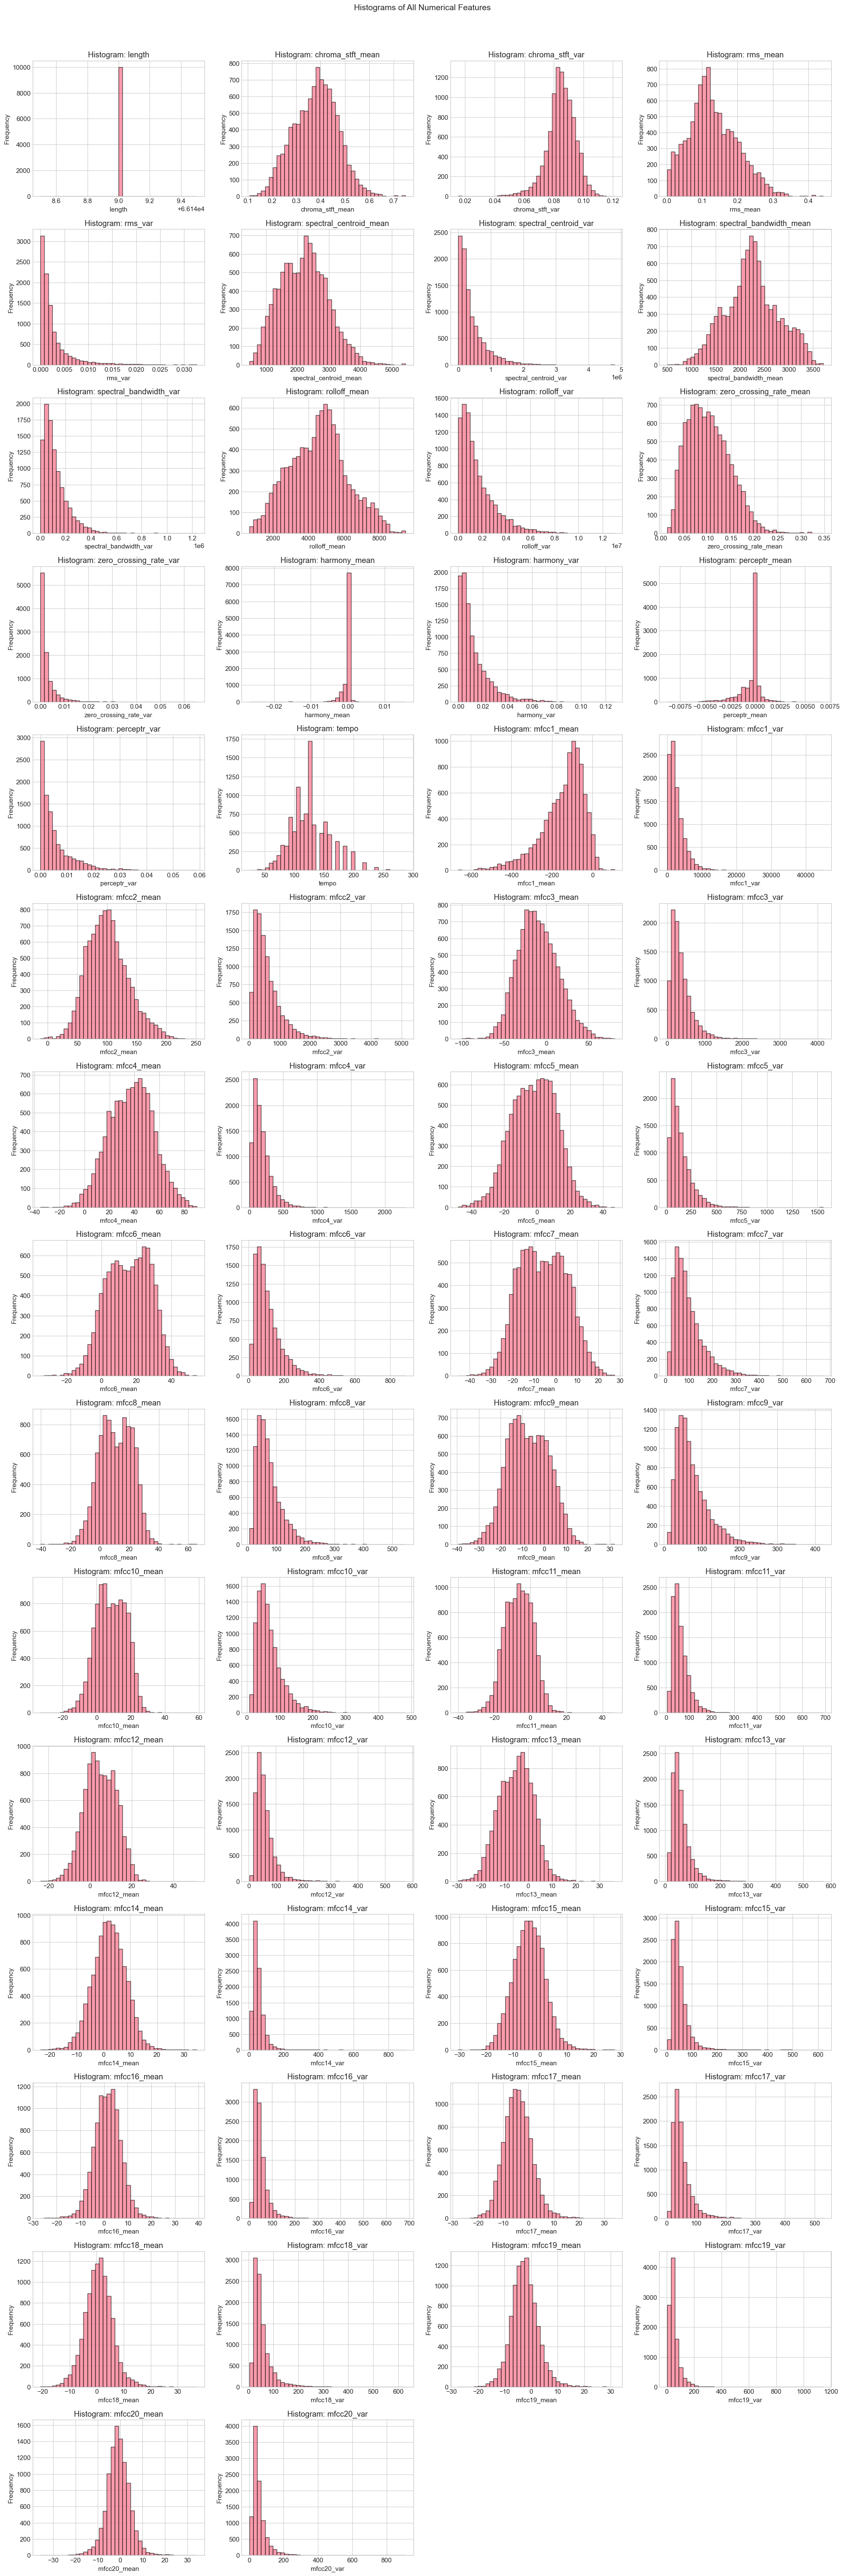

In [21]:
plot_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns]
n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df_clean[col], bins=40, edgecolor="black", alpha=0.7)
    axes[i].set_title(f"Histogram: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histograms of All Numerical Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


### Cell 22 — KDE Plots for Key Audio Features


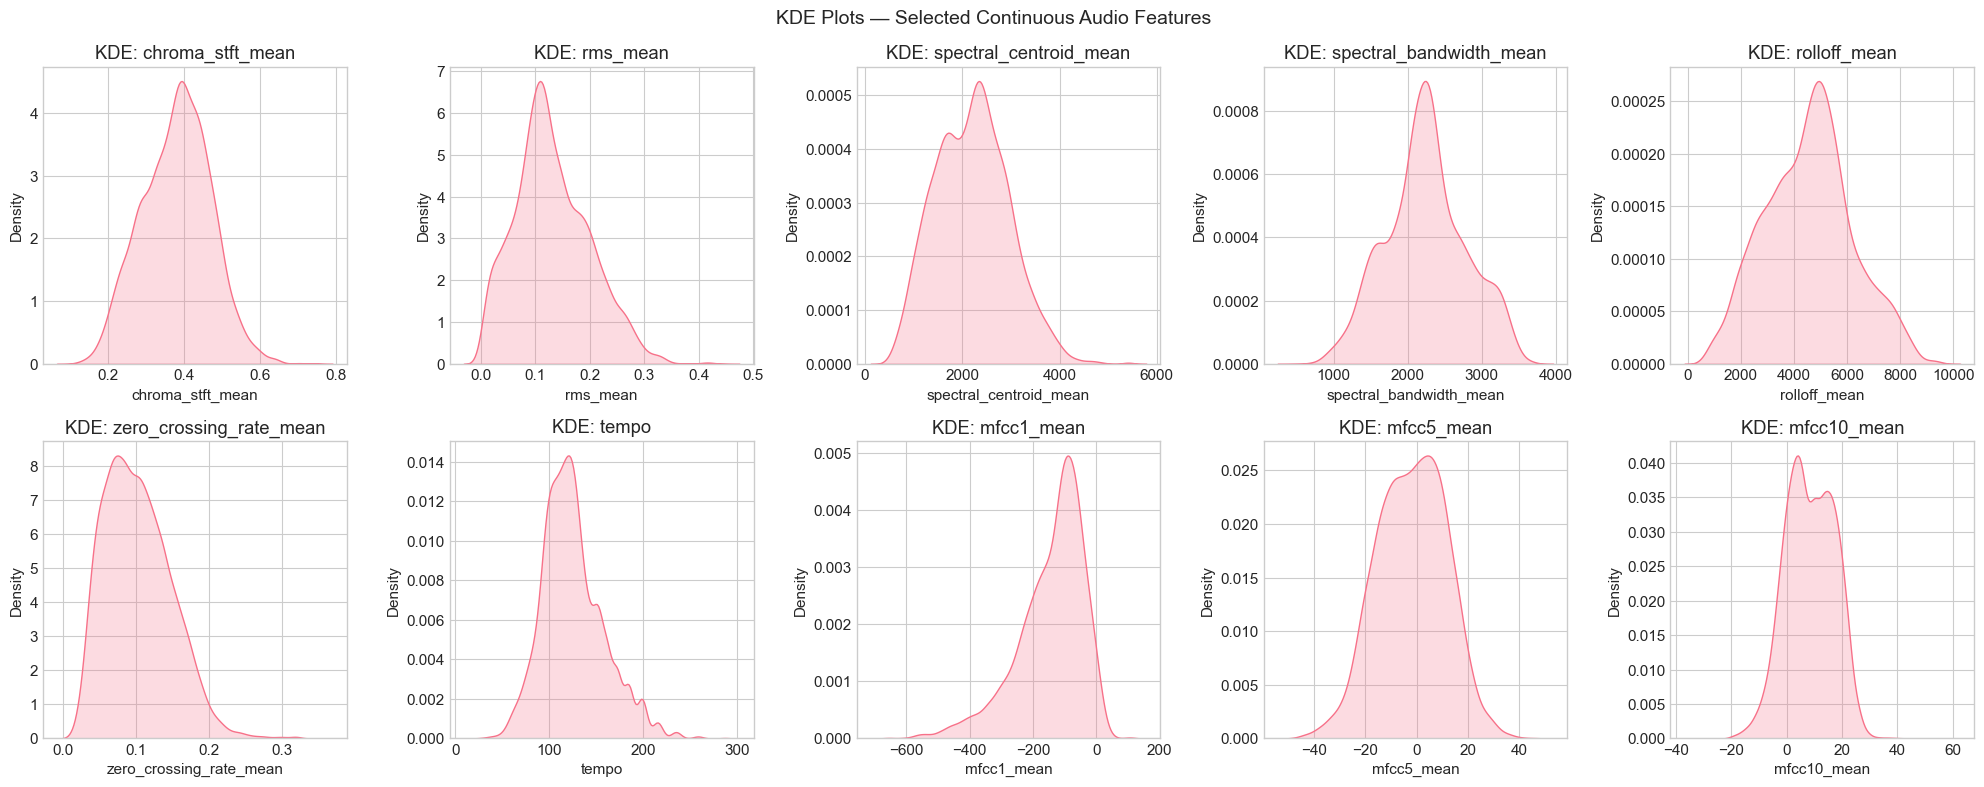

In [22]:
key_features = [
    "chroma_stft_mean", "rms_mean", "spectral_centroid_mean",
    "spectral_bandwidth_mean", "rolloff_mean", "zero_crossing_rate_mean",
    "tempo", "mfcc1_mean", "mfcc5_mean", "mfcc10_mean"
]
key_features = [f for f in key_features if f in df_clean.columns]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.kdeplot(data=df_clean, x=col, fill=True, ax=axes[i])
    axes[i].set_title(f"KDE: {col}")
    axes[i].set_xlabel(col)

for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("KDE Plots — Selected Continuous Audio Features", fontsize=14)
plt.tight_layout()
plt.show()


### Cell 23 — Boxplots for Selected Features


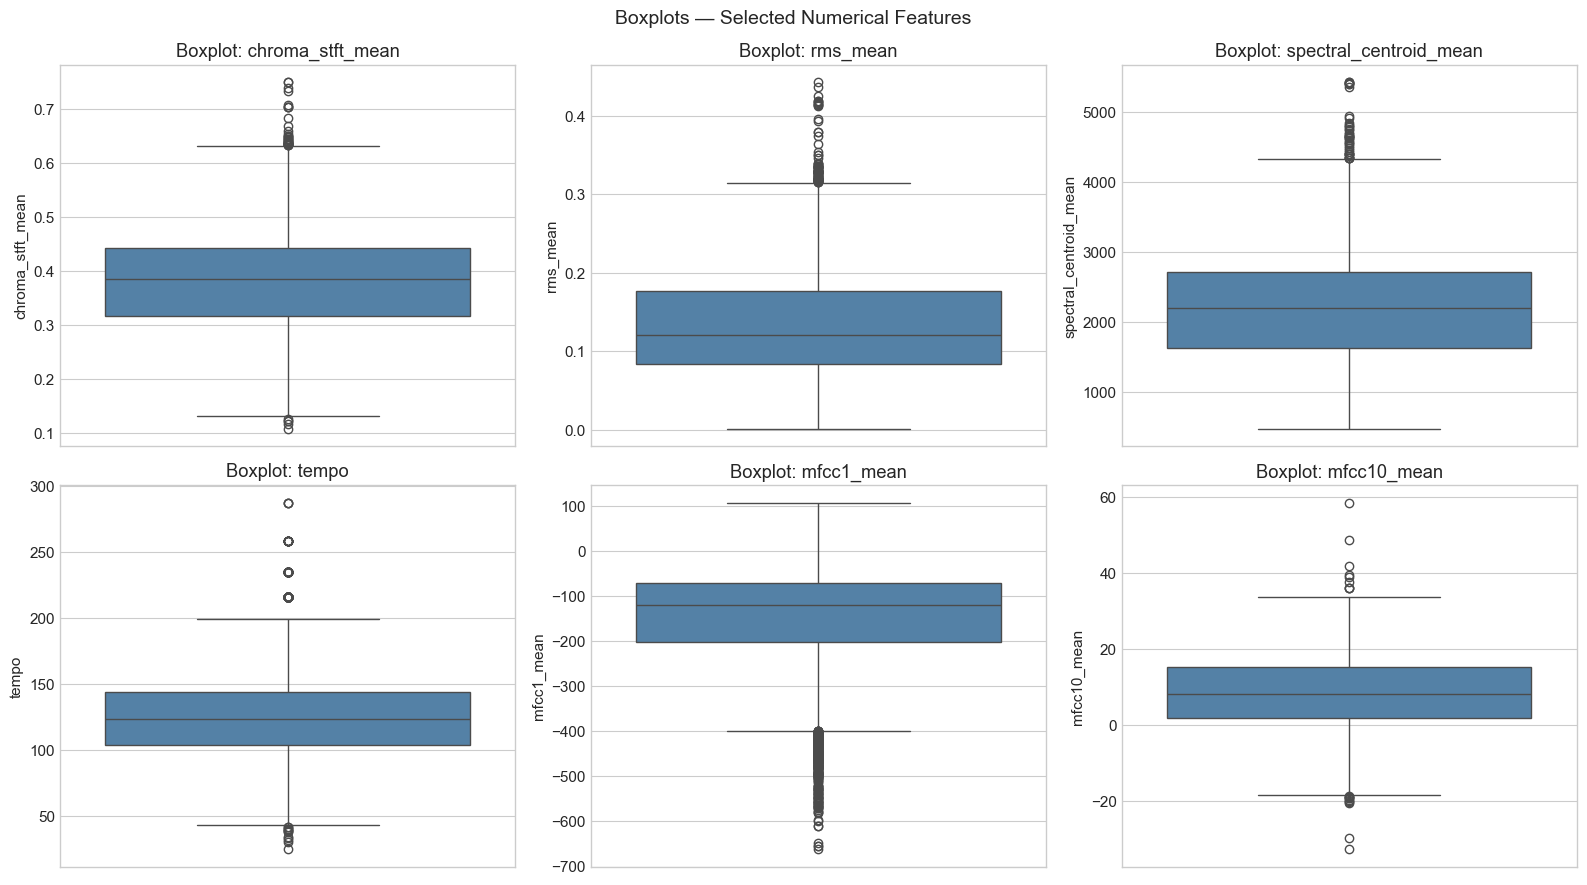

In [23]:
box_features = [
    "chroma_stft_mean", "rms_mean", "spectral_centroid_mean",
    "tempo", "mfcc1_mean", "mfcc10_mean"
]
box_features = [f for f in box_features if f in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(box_features):
    sns.boxplot(y=df_clean[col], ax=axes[i], color="steelblue")
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_ylabel(col)

plt.suptitle("Boxplots — Selected Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()


### Cell 24 — Violin Plots by Genre


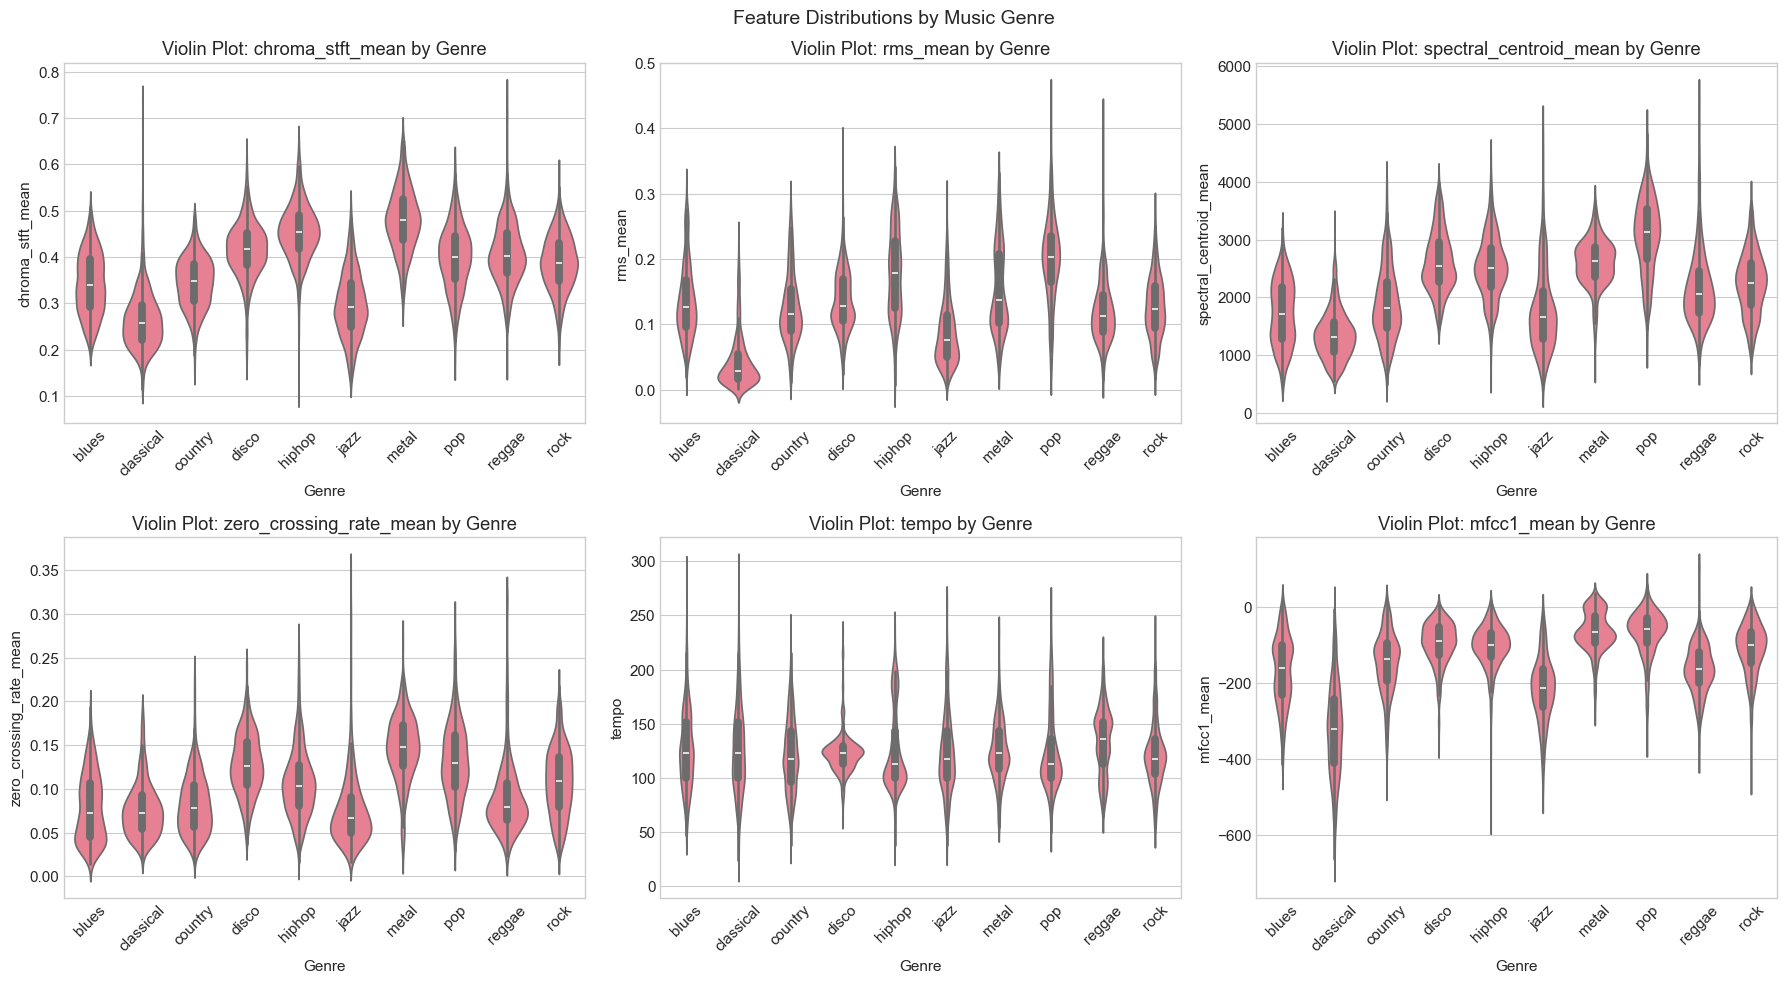

In [24]:
violin_features = [
    "chroma_stft_mean", "rms_mean", "spectral_centroid_mean",
    "zero_crossing_rate_mean", "tempo", "mfcc1_mean"
]
violin_features = [f for f in violin_features if f in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(violin_features):
    sns.violinplot(data=df_clean, x="label", y=col, order=order, ax=axes[i])
    axes[i].set_title(f"Violin Plot: {col} by Genre")
    axes[i].set_xlabel("Genre")
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Feature Distributions by Music Genre", fontsize=14)
plt.tight_layout()
plt.show()


### Cell 25 — Feature Distributions Grouped by Target


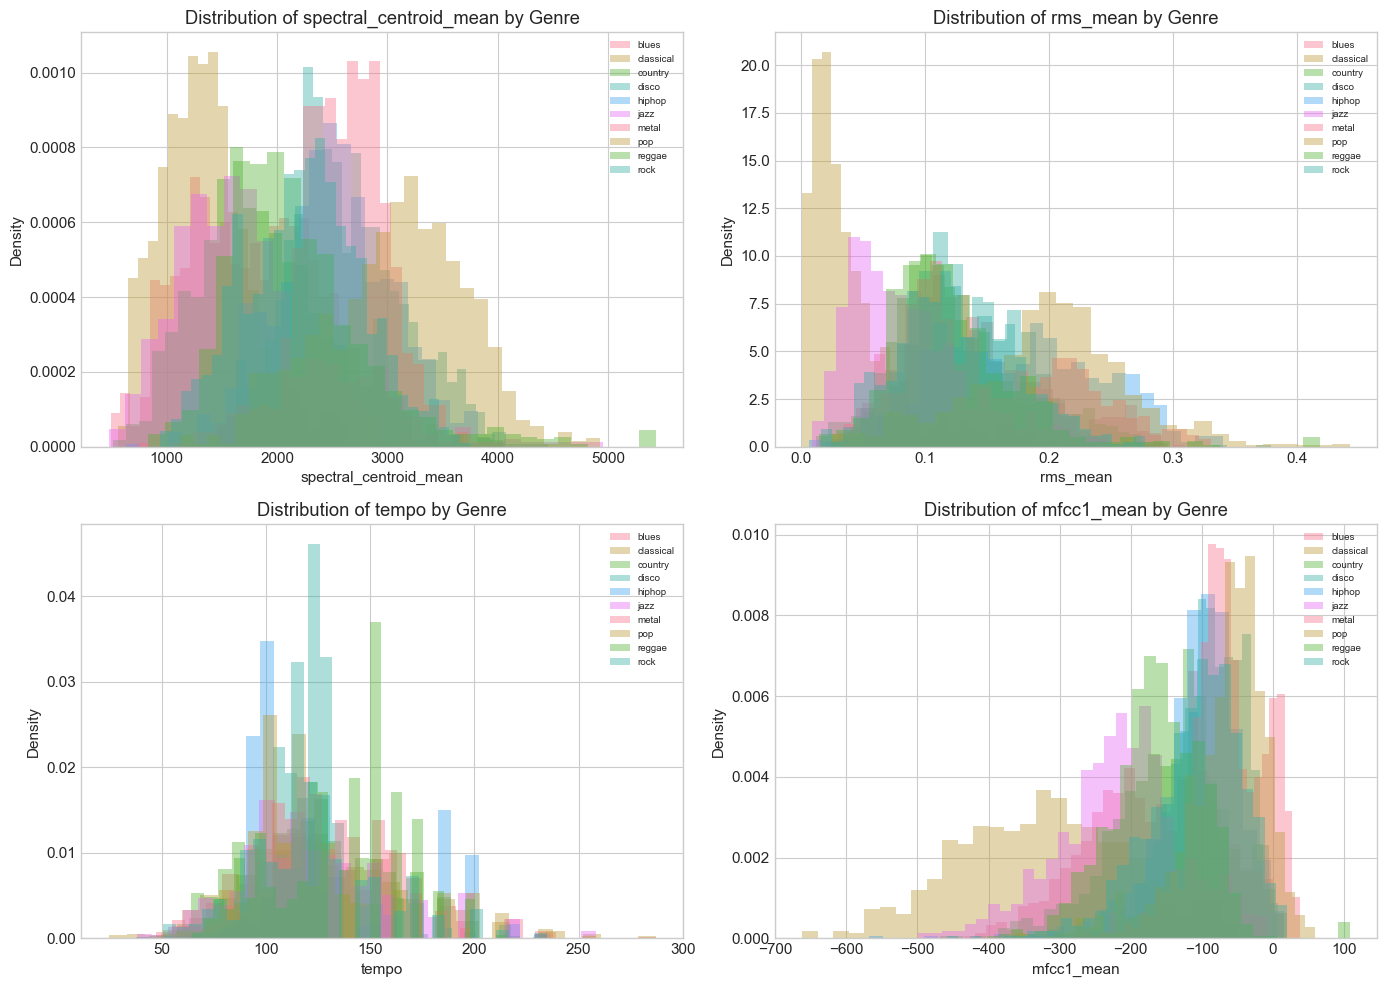

In [25]:
dist_by_label = ["spectral_centroid_mean", "rms_mean", "tempo", "mfcc1_mean"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(dist_by_label):
    for genre in order:
        subset = df_clean.loc[df_clean["label"] == genre, col]
        axes[i].hist(subset, bins=30, alpha=0.4, label=genre, density=True)
    axes[i].set_title(f"Distribution of {col} by Genre")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()


## PART 6 — Min, Max, Range, and Distribution Shape Analysis


### Cell 26 — Min, Max, and Range


In [26]:
num_cols_analysis = df_clean.select_dtypes(include=[np.number]).columns

min_max_range = pd.DataFrame({
    "min": df_clean[num_cols_analysis].min(),
    "max": df_clean[num_cols_analysis].max(),
})
min_max_range["range"] = min_max_range["max"] - min_max_range["min"]

print("Minimum, maximum, and range for each numerical column:")
display(min_max_range.round(4))


Minimum, maximum, and range for each numerical column:


,min,max,range
length,66149.0000,6.614900e+04,0.000000e+00
chroma_stft_mean,0.1071,7.495000e-01,6.424000e-01
chroma_stft_var,0.0153,1.210000e-01,1.056000e-01
rms_mean,0.0010,4.426000e-01,4.416000e-01
rms_var,0.0000,3.260000e-02,3.260000e-02
spectral_centroid_mean,472.7416,5.432534e+03,4.959793e+03
spectral_centroid_var,811.8813,4.794119e+06,4.793307e+06
spectral_bandwidth_mean,499.1629,3.708148e+03,3.208985e+03
spectral_bandwidth_var,1183.5203,1.235143e+06,1.233959e+06
rolloff_mean,658.3363,9.487447e+03,8.829110e+03


### Cell 27 — Variable Type Classification


In [27]:
def classify_column(col_name, series, target="label", id_col="filename"):
    if col_name == id_col:
        return "identifier"
    if col_name == target:
        return "categorical target"
    if col_name == target or col_name == id_col:
        pass
    if series.nunique() == 1:
        return "constant"
    if series.nunique() <= 10 and not pd.api.types.is_float_dtype(series):
        return "low-cardinality numeric"
    return "continuous numeric feature"

var_types = []
for col in df_clean.columns:
    var_types.append({
        "column": col,
        "variable_type": classify_column(col, df_clean[col])
    })

var_type_df = pd.DataFrame(var_types)
print("Variable type classification:")
display(var_type_df)


Variable type classification:


,column,variable_type
0,filename,identifier
1,length,constant
2,chroma_stft_mean,continuous numeric feature
3,chroma_stft_var,continuous numeric feature
4,rms_mean,continuous numeric feature
5,rms_var,continuous numeric feature
6,spectral_centroid_mean,continuous numeric feature
7,spectral_centroid_var,continuous numeric feature
8,spectral_bandwidth_mean,continuous numeric feature
9,spectral_bandwidth_var,continuous numeric feature


### Cell 28 — Skewness Analysis


Skewness of numeric features:


,skewness
mfcc14_var,5.4422
mfcc19_var,4.8024
mfcc15_var,4.2903
mfcc16_var,4.2749
mfcc20_var,4.0091
zero_crossing_rate_var,3.8693
mfcc1_var,3.6825
mfcc12_var,3.5557
mfcc18_var,3.2551
mfcc17_var,3.1342


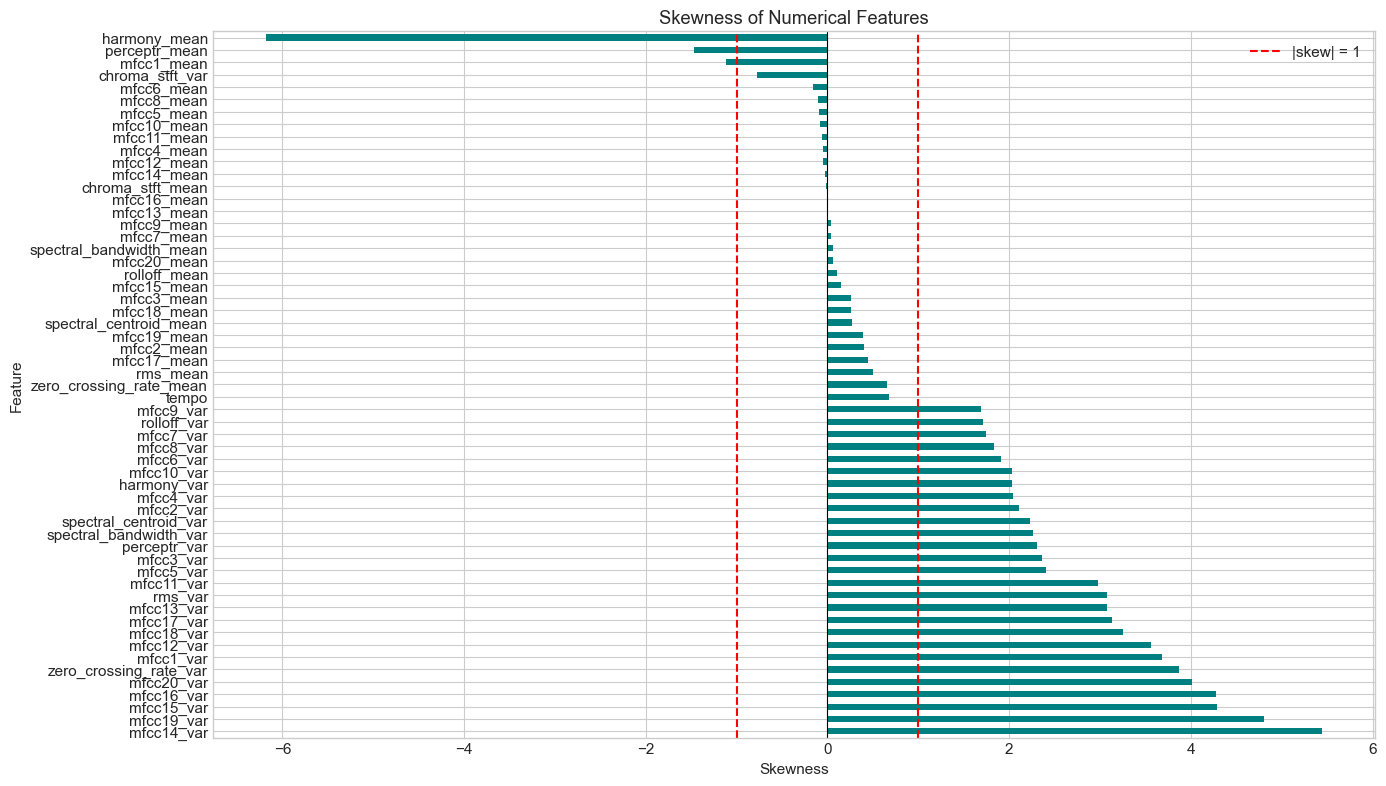


Highly skewed features (|skewness| > 1):


,skewness
mfcc14_var,5.442177
mfcc19_var,4.802354
mfcc15_var,4.290306
mfcc16_var,4.274885
mfcc20_var,4.009073
zero_crossing_rate_var,3.869302
mfcc1_var,3.682464
mfcc12_var,3.555652
mfcc18_var,3.255077
mfcc17_var,3.134224


Interpretation: Strong right/left tails suggest scaling or robust transforms
may help linear models, SVMs, neural networks, and k-NN.


In [28]:
# Exclude identifier; analyze numeric features only
skew_cols = [c for c in num_cols_analysis if c != "length" or df_clean["length"].nunique() > 1]
skewness = df_clean[skew_cols].skew().sort_values(ascending=False)

skew_df = skewness.to_frame(name="skewness")
print("Skewness of numeric features:")
display(skew_df.round(4))

# Bar plot
fig, ax = plt.subplots(figsize=(14, 8))
skewness.plot(kind="barh", ax=ax, color="teal")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(1, color="red", linestyle="--", label="|skew| = 1")
ax.axvline(-1, color="red", linestyle="--")
ax.set_title("Skewness of Numerical Features")
ax.set_xlabel("Skewness")
ax.set_ylabel("Feature")
ax.legend()
plt.tight_layout()
plt.show()

high_skew = skewness[skewness.abs() > 1]
print("\nHighly skewed features (|skewness| > 1):")
if len(high_skew) > 0:
    display(high_skew.to_frame(name="skewness"))
    print("Interpretation: Strong right/left tails suggest scaling or robust transforms")
    print("may help linear models, SVMs, neural networks, and k-NN.")
else:
    print("  No features exceed |skewness| > 1.")


### Cell 29 — Feature Scale Comparison and Scaling Rationale


In [29]:
feature_ranges = min_max_range["range"].sort_values(ascending=False)
print("Features with largest ranges (may dominate distance-based models):")
display(feature_ranges.head(10).to_frame(name="range"))

print("\nWhy scaling matters:")
print("- Logistic Regression: gradient-based optimization is sensitive to feature scale.")
print("- SVM: relies on distances/margins; unequal scales bias the model.")
print("- Neural Networks: faster convergence with normalized inputs.")
print("- k-NN: Euclidean distance dominated by large-scale features without scaling.")
print("\nTree-based models (Random Forest) are generally scale-invariant — unscaled features are acceptable.")
print("\nNote: Do not transform the target column in this section.")


Features with largest ranges (may dominate distance-based models):


,range
rolloff_var,1.298206e+07
spectral_centroid_var,4.793307e+06
spectral_bandwidth_var,1.233959e+06
mfcc1_var,4.500218e+04
rolloff_mean,8.829110e+03
mfcc2_var,5.122321e+03
spectral_centroid_mean,4.959793e+03
mfcc3_var,4.145731e+03
spectral_bandwidth_mean,3.208985e+03
mfcc4_var,2.300212e+03



Why scaling matters:
- Logistic Regression: gradient-based optimization is sensitive to feature scale.
- SVM: relies on distances/margins; unequal scales bias the model.
- Neural Networks: faster convergence with normalized inputs.
- k-NN: Euclidean distance dominated by large-scale features without scaling.

Tree-based models (Random Forest) are generally scale-invariant — unscaled features are acceptable.

Note: Do not transform the target column in this section.


## PART 7 — Correlation Analysis


### Cell 30 — Correlation Matrix and Heatmap


Correlation matrix shape: (58, 58)


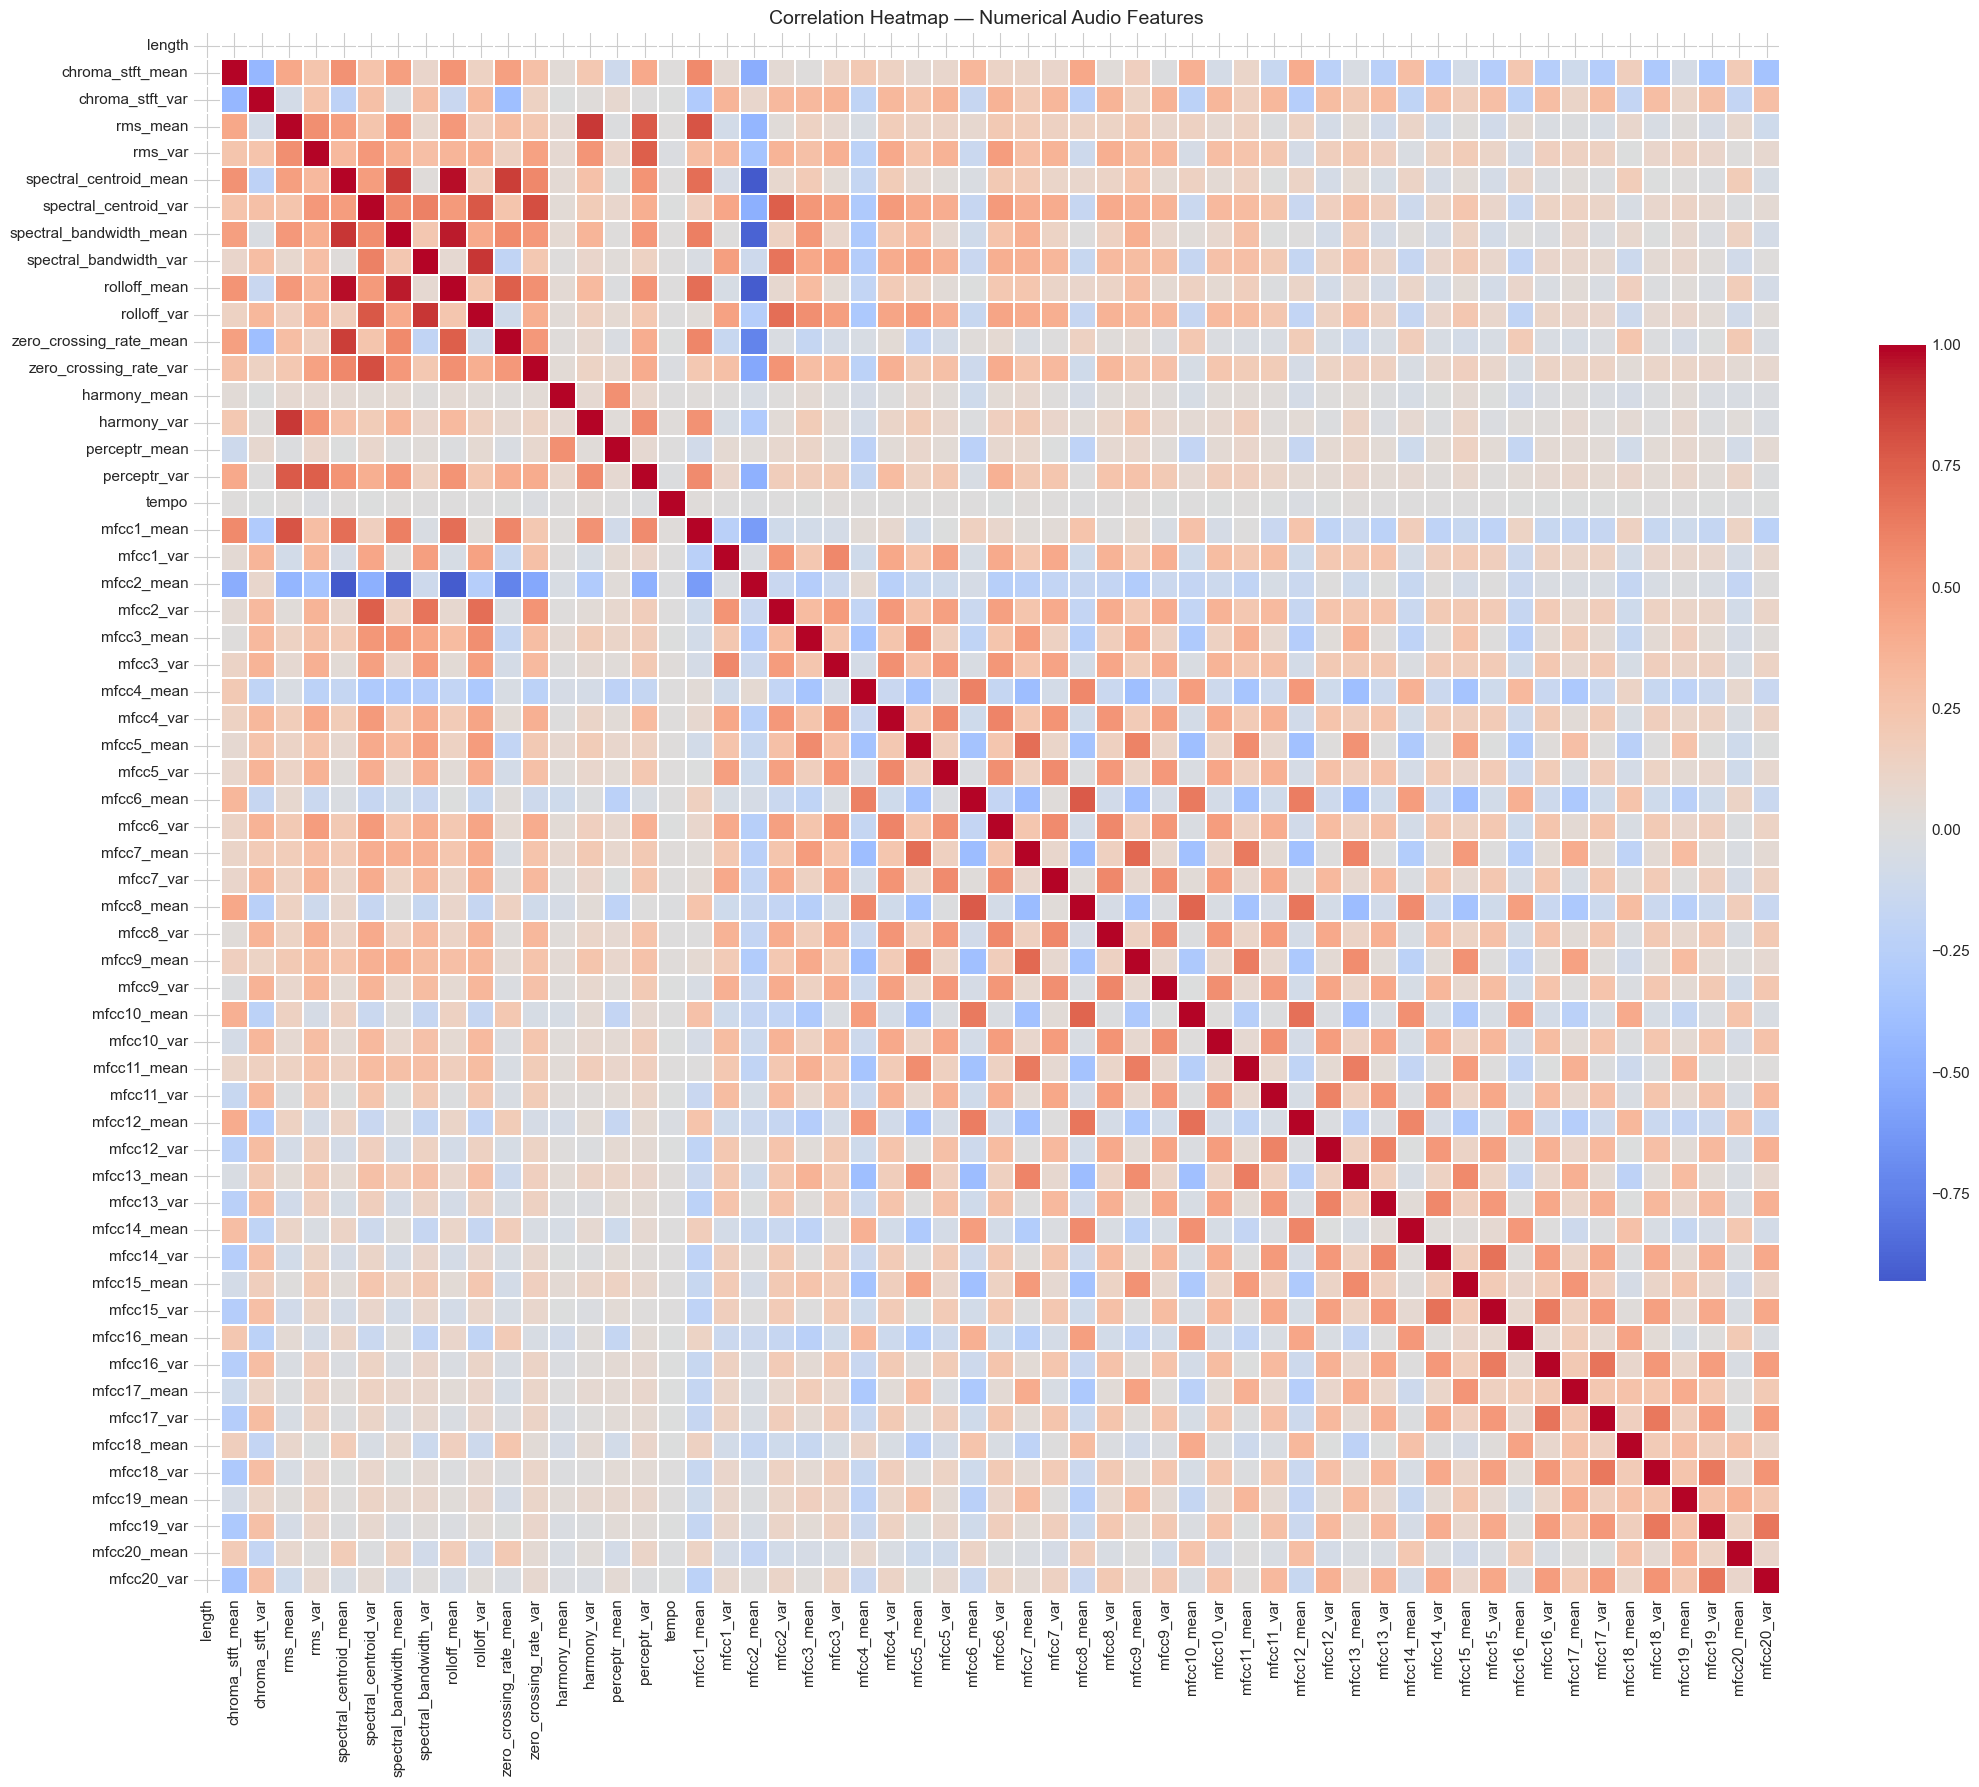

In [30]:
# Numerical features for correlation (exclude identifier; include length for completeness)
corr_features = [c for c in df_clean.columns if c not in ["filename", "label"]]
corr_matrix = df_clean[corr_features].corr()

print(f"Correlation matrix shape: {corr_matrix.shape}")

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=False,
            linewidths=0.1, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Correlation Heatmap — Numerical Audio Features", fontsize=14)
plt.tight_layout()
plt.show()


### Cell 31 — Highly Correlated Feature Pairs


In [31]:
THRESHOLD = 0.85

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > THRESHOLD:
            high_corr_pairs.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "correlation": round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    "correlation", key=abs, ascending=False
)

print(f"Highly correlated pairs (|r| > {THRESHOLD}):")
if len(high_corr_df) > 0:
    display(high_corr_df)
    print("\nMulticollinearity: Highly correlated features carry redundant information.")
    print("Linear models may suffer from unstable coefficients; tree-based models are less sensitive.")
else:
    print("  No pairs exceed the threshold.")


Highly correlated pairs (|r| > 0.85):


,feature_1,feature_2,correlation
2,spectral_centroid_mean,rolloff_mean,0.9744
5,spectral_bandwidth_mean,rolloff_mean,0.9510
4,spectral_centroid_mean,mfcc2_mean,-0.9314
8,rolloff_mean,mfcc2_mean,-0.9237
7,spectral_bandwidth_var,rolloff_var,0.8913
1,spectral_centroid_mean,spectral_bandwidth_mean,0.8904
6,spectral_bandwidth_mean,mfcc2_mean,-0.8872
0,rms_mean,harmony_var,0.8848
3,spectral_centroid_mean,zero_crossing_rate_mean,0.8655



Multicollinearity: Highly correlated features carry redundant information.
Linear models may suffer from unstable coefficients; tree-based models are less sensitive.


### Cell 32 — Feature Correlation with Encoded Target (Exploratory Only)


In [32]:
# Temporary encoding for EDA only — do NOT permanently replace label
le_eda = LabelEncoder()
y_encoded_eda = le_eda.fit_transform(df_clean["label"])

eda_df = df_clean[corr_features].copy()
eda_df["label_encoded"] = y_encoded_eda

target_corr = eda_df.corr()["label_encoded"].drop("label_encoded").sort_values(
    key=abs, ascending=False
)

print("Top 15 features by |correlation| with label-encoded target:")
display(target_corr.head(15).to_frame(name="correlation_with_encoded_label"))

print("\n⚠ Caution: Label encoding assigns arbitrary numeric order to genres.")
print("Pearson correlation with encoded multiclass labels is only an approximate exploratory measure.")
print("The original 'label' column in df_clean remains unchanged.")


Top 15 features by |correlation| with label-encoded target:


,correlation_with_encoded_label
spectral_bandwidth_mean,0.376621
rolloff_mean,0.369515
spectral_centroid_mean,0.360175
mfcc2_mean,-0.348035
chroma_stft_mean,0.330370
mfcc1_mean,0.326771
spectral_centroid_var,0.281352
rolloff_var,0.260298
zero_crossing_rate_mean,0.243590
zero_crossing_rate_var,0.215464



⚠ Caution: Label encoding assigns arbitrary numeric order to genres.
Pearson correlation with encoded multiclass labels is only an approximate exploratory measure.
The original 'label' column in df_clean remains unchanged.


## PART 8 — Class-Wise Feature Analysis


### Cell 33 — Mean, Median, Std by Genre


In [33]:
genre_groups = df_clean.groupby("label")

mean_by_genre = genre_groups[numeric_feature_cols].mean()
median_by_genre = genre_groups[numeric_feature_cols].median()
std_by_genre = genre_groups[numeric_feature_cols].std()

print("Mean feature values by genre (sample):")
display(mean_by_genre.iloc[:, :8].round(4))

print("\nMedian feature values by genre (sample):")
display(median_by_genre.iloc[:, :8].round(4))

print("\nStandard deviation by genre (sample):")
display(std_by_genre.iloc[:, :8].round(4))


Mean feature values by genre (sample):


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean
label,,,,,,,,
blues,66149.0,0.3424,0.0899,0.1360,0.0026,1726.0679,245598.2196,1930.8497
classical,66149.0,0.2645,0.0834,0.0428,0.0004,1351.3201,70830.2306,1519.5316
country,66149.0,0.3450,0.0854,0.1257,0.0014,1891.1876,328737.7613,2096.4073
disco,66149.0,0.4164,0.0834,0.1362,0.0027,2617.2850,466543.4850,2512.3558
hiphop,66149.0,0.4546,0.0868,0.1782,0.0067,2521.5184,703894.9642,2512.2845
jazz,66149.0,0.2975,0.0880,0.0866,0.0012,1790.2817,206724.0080,2019.7643
metal,66149.0,0.4802,0.0724,0.1535,0.0011,2600.8817,183577.3353,2242.8198
pop,66149.0,0.3981,0.0877,0.1996,0.0065,3069.9930,876099.9767,3006.8030
reggae,66149.0,0.4090,0.0893,0.1224,0.0029,2182.2136,708041.2991,2309.7967



Median feature values by genre (sample):


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean
label,,,,,,,,
blues,66149.0,0.3393,0.0898,0.1263,0.0021,1720.8352,179008.4486,1969.3978
classical,66149.0,0.2578,0.0832,0.0292,0.0001,1317.0437,41867.3442,1510.3854
country,66149.0,0.3479,0.0850,0.1152,0.0011,1808.1131,249475.2186,2051.0139
disco,66149.0,0.4177,0.0831,0.1278,0.0022,2541.2888,396300.8398,2444.6635
hiphop,66149.0,0.4535,0.0873,0.1785,0.0048,2510.3259,575990.1904,2463.5471
jazz,66149.0,0.2912,0.0876,0.0762,0.0007,1657.9831,141408.1844,1965.5197
metal,66149.0,0.4798,0.0732,0.1368,0.0007,2627.9256,138874.5860,2247.5146
pop,66149.0,0.4002,0.0882,0.2031,0.0057,3129.2922,769616.0811,3088.0193
reggae,66149.0,0.4020,0.0901,0.1128,0.0020,2055.5659,586928.8142,2236.0865



Standard deviation by genre (sample):


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean
label,,,,,,,,
blues,0.0,0.0659,0.0079,0.0555,0.0022,554.5778,223351.0280,356.1464
classical,0.0,0.0624,0.0056,0.0405,0.0007,412.9347,112099.9587,311.5523
country,0.0,0.0548,0.0065,0.0524,0.0010,611.3965,270622.1690,462.6871
disco,0.0,0.0591,0.0080,0.0451,0.0021,510.2316,325691.8026,368.0374
hiphop,0.0,0.0599,0.0098,0.0650,0.0060,542.2189,528410.2867,374.7213
jazz,0.0,0.0700,0.0070,0.0484,0.0013,723.0241,219396.9362,582.7492
metal,0.0,0.0673,0.0108,0.0659,0.0011,409.3339,146862.8540,225.4394
pop,0.0,0.0703,0.0088,0.0646,0.0052,646.8136,550999.8604,353.3657
reggae,0.0,0.0687,0.0095,0.0531,0.0027,674.5192,493499.0476,407.6493


### Cell 34 — Class-Wise Mean Heatmaps


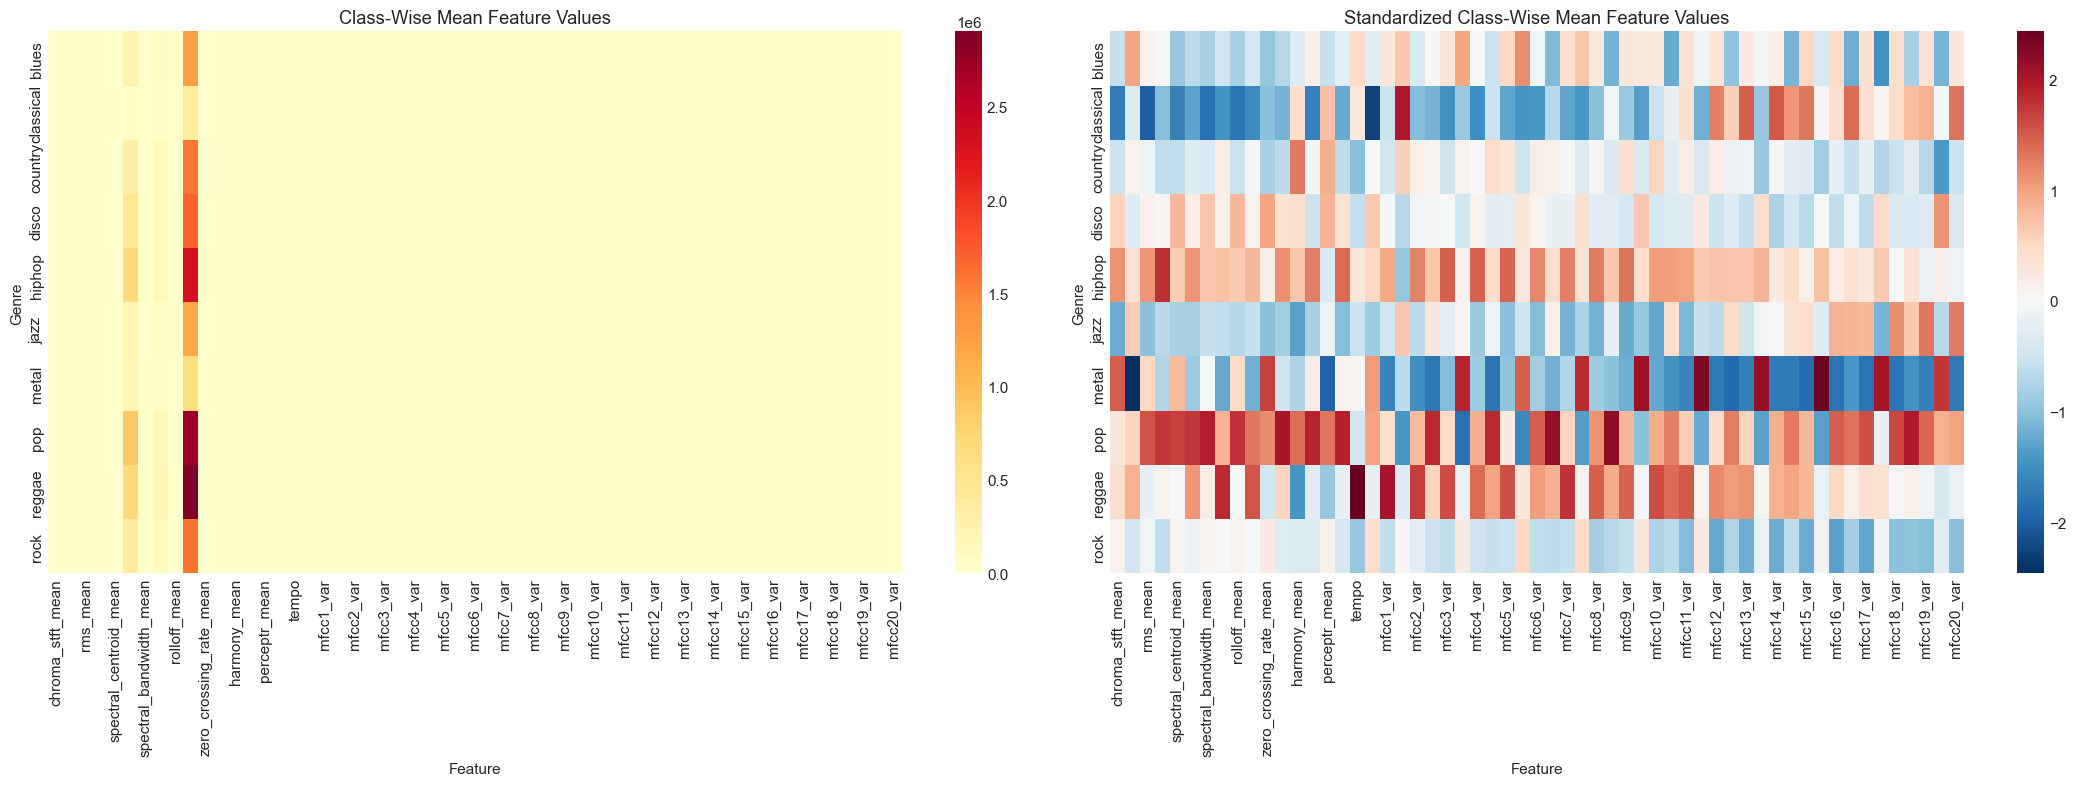

In [34]:
# Drop length if constant for cleaner heatmap
heatmap_features = [c for c in numeric_feature_cols if df_clean[c].nunique() > 1]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Raw means
sns.heatmap(mean_by_genre[heatmap_features], cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Class-Wise Mean Feature Values")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Genre")

# Standardized (z-score across genres for each feature)
mean_std = (mean_by_genre[heatmap_features] - mean_by_genre[heatmap_features].mean()) / (
    mean_by_genre[heatmap_features].std() + 1e-8
)
sns.heatmap(mean_std, cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Standardized Class-Wise Mean Feature Values")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Genre")

plt.tight_layout()
plt.show()


### Cell 35 — Top Features with Largest Cross-Genre Variation


In [35]:
# Range of class means per feature — larger range => more separation potential
mean_range_across_genres = mean_by_genre.max() - mean_by_genre.min()
top_varying = mean_range_across_genres.sort_values(ascending=False).head(15)

print("Top 15 features with largest variation in class means:")
display(top_varying.to_frame(name="mean_range_across_genres"))


Top 15 features with largest variation in class means:


,mean_range_across_genres
rolloff_var,2.541187e+06
spectral_centroid_var,8.052697e+05
spectral_bandwidth_var,1.601525e+05
rolloff_mean,4.171814e+03
mfcc1_var,3.838332e+03
spectral_centroid_mean,1.718673e+03
spectral_bandwidth_mean,1.487271e+03
mfcc2_var,6.178924e+02
mfcc3_var,4.308330e+02
mfcc1_mean,2.608605e+02


### Cell 36 — Grouped Boxplots for Genre Separability


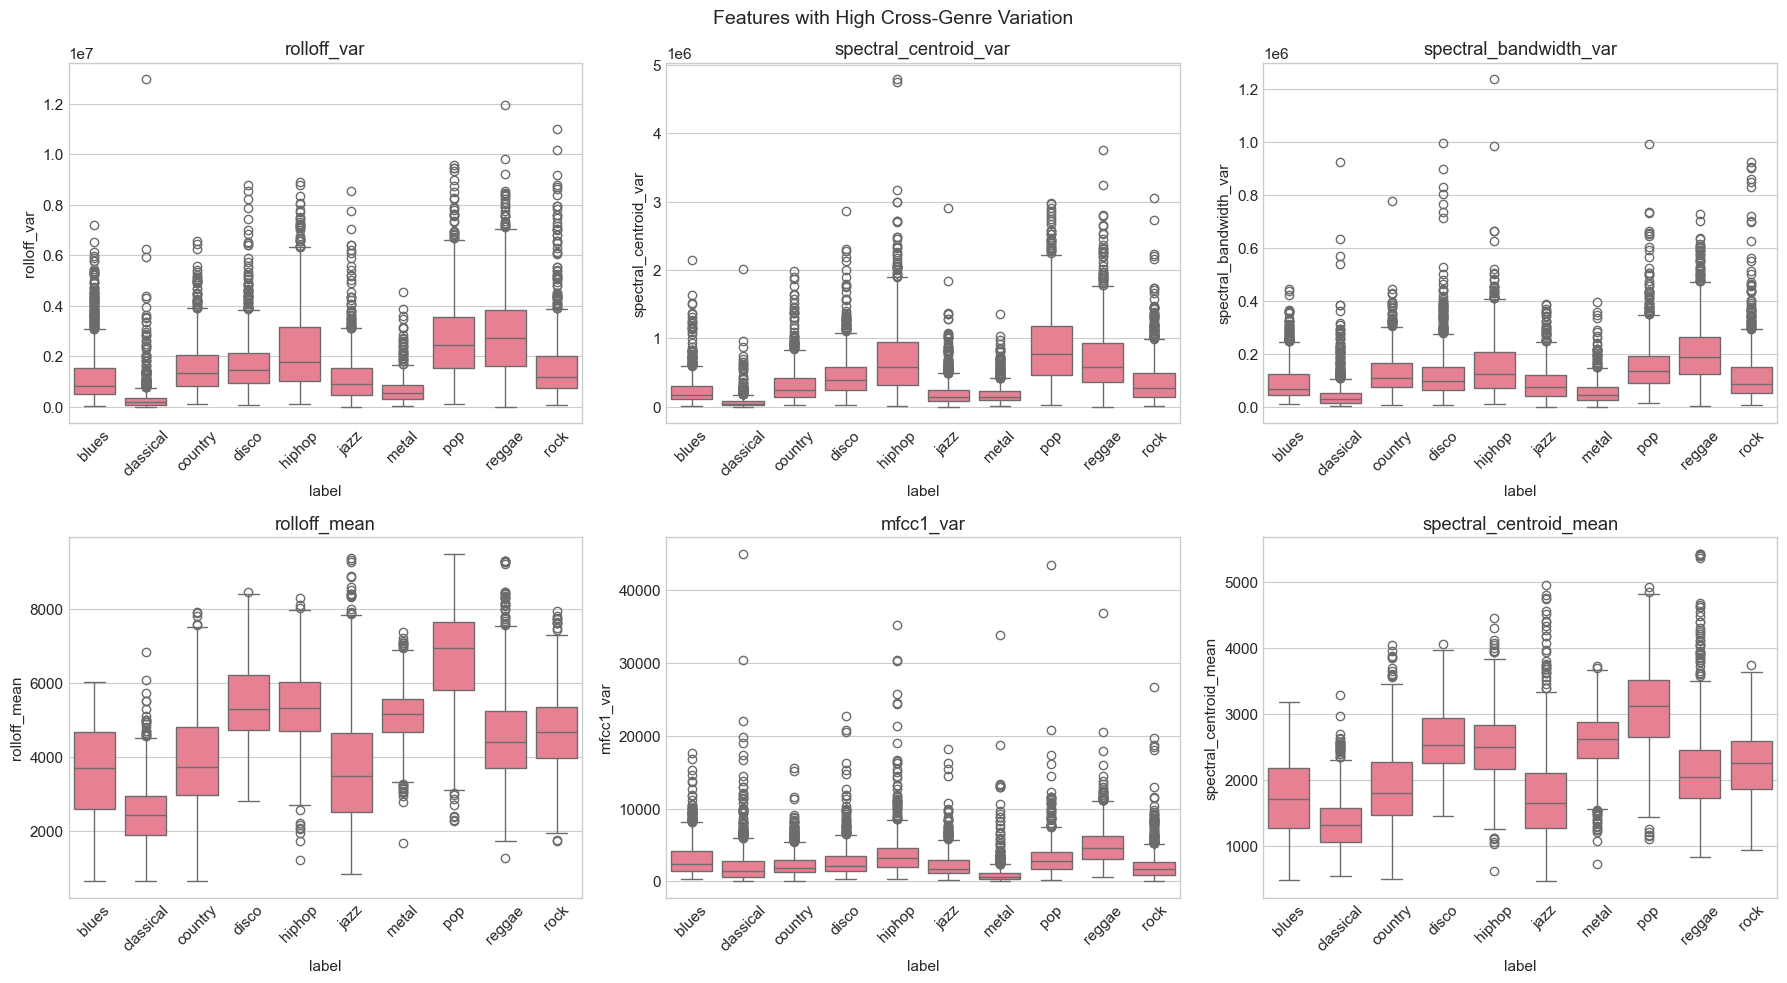

Some genres show clearer separation on spectral and MFCC features.
Statistical separability does not guarantee strong out-of-sample predictive performance.


In [36]:
separable_features = top_varying.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(separable_features):
    sns.boxplot(data=df_clean, x="label", y=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Features with High Cross-Genre Variation", fontsize=14)
plt.tight_layout()
plt.show()

print("Some genres show clearer separation on spectral and MFCC features.")
print("Statistical separability does not guarantee strong out-of-sample predictive performance.")


### Cell 37 — ANOVA / Kruskal-Wallis Tests Across Genres


In [37]:
# Use Kruskal-Wallis (non-parametric) for robustness; ANOVA for comparison
test_results = []
genres = df_clean["label"].unique()

for col in heatmap_features:
    groups = [df_clean.loc[df_clean["label"] == g, col].values for g in genres]
    # Kruskal-Wallis
    kw_stat, kw_p = stats.kruskal(*groups)
    # One-way ANOVA
    f_stat, f_p = stats.f_oneway(*groups)
    test_results.append({
        "feature": col,
        "kruskal_statistic": kw_stat,
        "kruskal_p_value": kw_p,
        "anova_f_statistic": f_stat,
        "anova_p_value": f_p,
        "significant_0.05": kw_p < 0.05,
        "interpretation": "Significant across genres" if kw_p < 0.05 else "Not significant"
    })

test_df = pd.DataFrame(test_results).sort_values("kruskal_p_value")
sig_count = test_df["significant_0.05"].sum()
print(f"Features with significant Kruskal-Wallis test (p < 0.05): {sig_count} / {len(test_df)}")
display(test_df.head(20).round(6))

print("\nNote: Statistical significance indicates distributional differences across genres,")
print("but does not automatically imply strong predictive power or generalization.")


Features with significant Kruskal-Wallis test (p < 0.05): 57 / 57


,feature,kruskal_statistic,kruskal_p_value,anova_f_statistic,anova_p_value,significant_0.05,interpretation
0,chroma_stft_mean,5017.797790,0.0,1108.933812,0.0,True,Significant across genres
1,chroma_stft_var,2237.327616,0.0,370.691162,0.0,True,Significant across genres
2,rms_mean,3677.523956,0.0,649.566452,0.0,True,Significant across genres
3,rms_var,4528.894139,0.0,574.604009,0.0,True,Significant across genres
4,spectral_centroid_mean,4417.597477,0.0,821.478589,0.0,True,Significant across genres
5,spectral_centroid_var,4850.237968,0.0,564.027251,0.0,True,Significant across genres
6,spectral_bandwidth_mean,4601.205378,0.0,1031.858577,0.0,True,Significant across genres
7,spectral_bandwidth_var,3002.474253,0.0,284.502929,0.0,True,Significant across genres
8,rolloff_mean,4507.307277,0.0,950.369053,0.0,True,Significant across genres
9,rolloff_var,4035.911233,0.0,428.928159,0.0,True,Significant across genres



Note: Statistical significance indicates distributional differences across genres,
but does not automatically imply strong predictive power or generalization.


## PART 9 — Outlier Detection and Visualization


Outliers in audio features may reflect genuine musical variation rather than errors.  
We document outliers but avoid blind removal. Capping (if applied) uses a separate dataframe.


### Cell 38 — IQR Outlier Detection


In [38]:
def iqr_outlier_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

outlier_rows = []
for col in heatmap_features:
    lower, upper = iqr_outlier_bounds(df_clean[col])
    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    n_out = mask.sum()
    outlier_rows.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": n_out,
        "outlier_pct": round(100 * n_out / len(df_clean), 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
print("IQR outlier summary (top 15 by percentage):")
display(outlier_summary.head(15).round(4))


IQR outlier summary (top 15 by percentage):


,feature,lower_bound,upper_bound,n_outliers,outlier_pct
12,harmony_mean,-0.0003,2.000000e-04,2175,21.77
14,perceptr_mean,-0.0015,9.000000e-04,1461,14.62
11,zero_crossing_rate_var,-0.0030,6.700000e-03,906,9.07
3,rms_var,-0.0032,6.900000e-03,904,9.05
56,mfcc20_var,-27.2872,1.255090e+02,676,6.77
54,mfcc19_var,-21.7519,1.175769e+02,655,6.56
52,mfcc18_var,-18.9604,1.106305e+02,636,6.37
15,perceptr_var,-0.0085,1.710000e-02,632,6.33
5,spectral_centroid_var,-535632.5470,1.221244e+06,593,5.94
50,mfcc17_var,-17.8568,1.093972e+02,582,5.83


### Cell 39 — Z-Score Outlier Detection


In [39]:
Z_THRESHOLD = 3
z_outlier_rows = []

for col in heatmap_features:
    z = np.abs(stats.zscore(df_clean[col], nan_policy="omit"))
    n_out = (z > Z_THRESHOLD).sum()
    z_outlier_rows.append({
        "feature": col,
        "n_outliers_z": n_out,
        "outlier_pct_z": round(100 * n_out / len(df_clean), 2)
    })

z_outlier_df = pd.DataFrame(z_outlier_rows).sort_values("outlier_pct_z", ascending=False)
print(f"Z-score outliers (|z| > {Z_THRESHOLD}) — top 15:")
display(z_outlier_df.head(15))


Z-score outliers (|z| > 3) — top 15:


,feature,n_outliers_z,outlier_pct_z
3,rms_var,270,2.70
14,perceptr_mean,270,2.70
13,harmony_var,226,2.26
11,zero_crossing_rate_var,217,2.17
52,mfcc18_var,210,2.10
15,perceptr_var,204,2.04
5,spectral_centroid_var,204,2.04
50,mfcc17_var,198,1.98
9,rolloff_var,187,1.87
56,mfcc20_var,185,1.85


### Cell 40 — Outlier Boxplots and Academic Interpretation


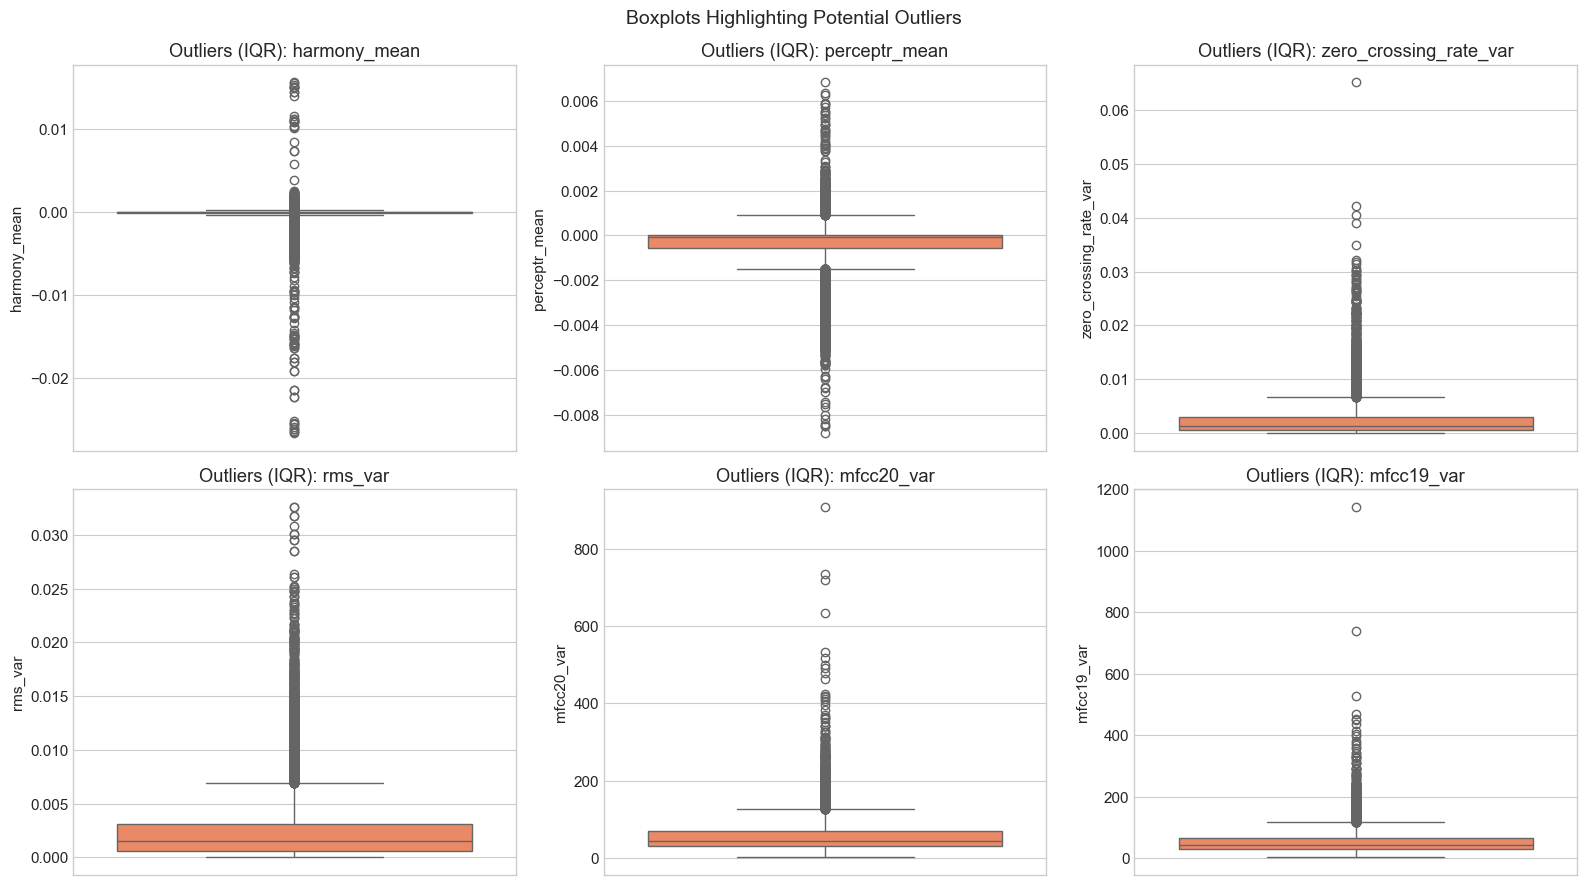

Interpretation:
- Outliers may represent valid extreme musical characteristics (e.g., metal energy, classical dynamics).
- Tree-based models: typically keep outliers.
- Linear/NN models: consider RobustScaler or percentile capping only if justified.


In [40]:
outlier_plot_features = outlier_summary.head(6)["feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(outlier_plot_features):
    sns.boxplot(y=df_clean[col], ax=axes[i], color="coral")
    axes[i].set_title(f"Outliers (IQR): {col}")

plt.suptitle("Boxplots Highlighting Potential Outliers", fontsize=14)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Outliers may represent valid extreme musical characteristics (e.g., metal energy, classical dynamics).")
print("- Tree-based models: typically keep outliers.")
print("- Linear/NN models: consider RobustScaler or percentile capping only if justified.")


### Cell 41 — Optional Percentile Capping (Separate DataFrame)


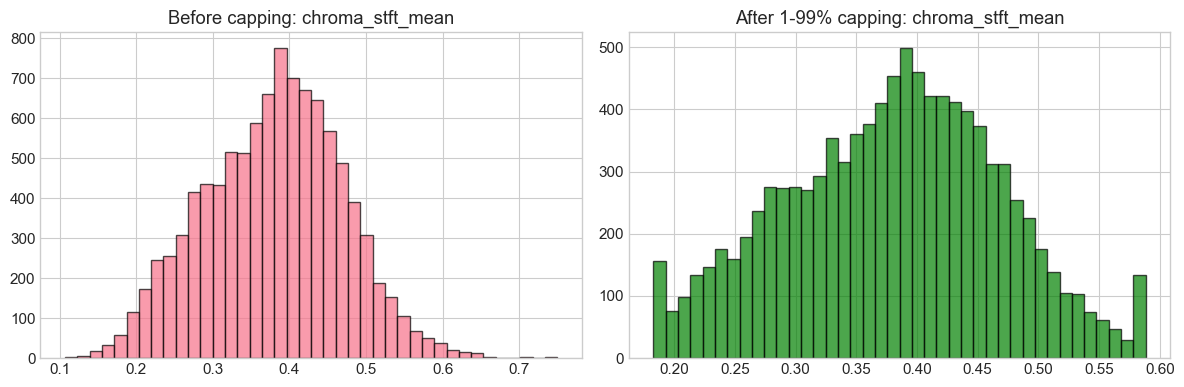

df_capped created for optional use. Primary preprocessing uses df_clean.
Capping is NOT applied to the main train/test pipeline unless explicitly chosen later.


In [41]:
# Create df_capped only as an optional variant — df_clean remains unchanged
LOW_PCT, HIGH_PCT = 1, 99

df_capped = df_clean.copy()
for col in heatmap_features:
    low = df_clean[col].quantile(LOW_PCT / 100)
    high = df_clean[col].quantile(HIGH_PCT / 100)
    df_capped[col] = df_clean[col].clip(lower=low, upper=high)

# Visual comparison for one feature
example_col = heatmap_features[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean[example_col], bins=40, alpha=0.7, edgecolor="black")
axes[0].set_title(f"Before capping: {example_col}")
axes[1].hist(df_capped[example_col], bins=40, alpha=0.7, edgecolor="black", color="green")
axes[1].set_title(f"After {LOW_PCT}-{HIGH_PCT}% capping: {example_col}")
plt.tight_layout()
plt.show()

print("df_capped created for optional use. Primary preprocessing uses df_clean.")
print("Capping is NOT applied to the main train/test pipeline unless explicitly chosen later.")


## PART 10 — Preprocessing Strategy


**Pipeline principles:**
- Drop `filename` (identifier)
- Drop constant `length` if applicable
- Encode target with `LabelEncoder`
- Split before scaling; fit `StandardScaler` on training data only
- Create scaled and unscaled versions for different model families


### Cell 42 — Separate Features and Target


In [42]:
# Start from cleaned data
df_prep = df_clean.copy()

# Separate X and y
y = df_prep["label"].copy()
X = df_prep.drop(columns=["label"])

print(f"X shape (with identifier): {X.shape}")
print(f"y shape: {y.shape}")


X shape (with identifier): (9990, 59)
y shape: (9990,)


### Cell 43 — Drop Identifier and Constant Columns


In [43]:
cols_to_drop = ["filename"]

# Drop length if constant or near-constant
if X["length"].nunique() <= 1:
    cols_to_drop.append("length")
    print("'length' is constant — dropped from predictive features.")

X_model = X.drop(columns=cols_to_drop)

print(f"Columns dropped: {cols_to_drop}")
print(f"X_model shape after dropping: {X_model.shape}")
print(f"Feature columns ({len(X_model.columns)}):")
print(list(X_model.columns))


'length' is constant — dropped from predictive features.
Columns dropped: ['filename', 'length']
X_model shape after dropping: (9990, 57)
Feature columns (57):
['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean

### Cell 44 — Encode Target and Save Mapping


In [44]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_mapping = pd.DataFrame({
    "encoded_label": label_encoder.transform(label_encoder.classes_),
    "genre_name": label_encoder.classes_
})

print("Label encoding mapping:")
display(class_mapping)

# For sklearn split, use encoded labels
y = pd.Series(y_encoded, name="label_encoded")


Label encoding mapping:


,encoded_label,genre_name
0,0,blues
1,1,classical
2,2,country
3,3,disco
4,4,hiphop
5,5,jazz
6,6,metal
7,7,pop
8,8,reggae
9,9,rock


### Cell 45 — Train-Test Split (Stratified)


In [45]:
X_train_tree, X_test_tree, y_train, y_test = train_test_split(
    X_model, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train_tree shape: {X_train_tree.shape}")
print(f"X_test_tree shape:  {X_test_tree.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train_tree shape: (7992, 57)
X_test_tree shape:  (1998, 57)
y_train shape: (7992,)
y_test shape:  (1998,)


### Cell 46 — StandardScaler (Fit on Train Only)


In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_tree)
X_test_scaled = scaler.transform(X_test_tree)

# Convert back to DataFrames for inspection and saving
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_model.columns, index=X_train_tree.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_model.columns, index=X_test_tree.index)

print("Scaler fitted on X_train only (no data leakage).")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"X_train_scaled std (should be ~1):  {X_train_scaled.std().mean():.6f}")


Scaler fitted on X_train only (no data leakage).
X_train_scaled mean (should be ~0): -0.000000
X_train_scaled std (should be ~1):  1.000063


### Cell 47 — Prepared Dataset Summary


In [47]:
print("=" * 60)
print("PREPARED DATASETS FOR DOWNSTREAM MODELING")
print("=" * 60)
print("\nVersion 1 — Scaled (Linear Classifier, Neural Network, SVM, k-NN):")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")

print("\nVersion 2 — Unscaled (Random Forest and tree-based models):")
print(f"  X_train_tree: {X_train_tree.shape}")
print(f"  X_test_tree:  {X_test_tree.shape}")

print("\nTarget:")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

print("\nArtifacts:")
print(f"  label_encoder: {label_encoder.classes_}")
print("  class_mapping: saved in Part 12")


PREPARED DATASETS FOR DOWNSTREAM MODELING

Version 1 — Scaled (Linear Classifier, Neural Network, SVM, k-NN):
  X_train_scaled: (7992, 57)
  X_test_scaled:  (1998, 57)

Version 2 — Unscaled (Random Forest and tree-based models):
  X_train_tree: (7992, 57)
  X_test_tree:  (1998, 57)

Target:
  y_train: (7992,)
  y_test:  (1998,)

Artifacts:
  label_encoder: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
  class_mapping: saved in Part 12


## PART 11 — Before and After Preprocessing Comparison


### Cell 48 — Shape Comparisons


In [48]:
comparisons = [
    ("Original loaded data (df)", df_original.shape),
    ("After duplicate removal (df_clean)", df_clean.shape),
    ("After dropping ID/constant cols (X_model)", X_model.shape),
    ("X_train_tree", X_train_tree.shape),
    ("X_test_tree", X_test_tree.shape),
    ("X_train_scaled", X_train_scaled.shape),
    ("X_test_scaled", X_test_scaled.shape),
]

comp_df = pd.DataFrame(comparisons, columns=["Stage", "Shape"])
print("Shape at each preprocessing stage:")
display(comp_df)


Shape at each preprocessing stage:


,Stage,Shape
0,Original loaded data (df),"(9990, 60)"
1,After duplicate removal (df_clean),"(9990, 60)"
2,After dropping ID/constant cols (X_model),"(9990, 57)"
3,X_train_tree,"(7992, 57)"
4,X_test_tree,"(1998, 57)"
5,X_train_scaled,"(7992, 57)"
6,X_test_scaled,"(1998, 57)"


### Cell 49 — Missing Values Before and After


In [49]:
print(f"Missing values in original df: {df_original.isnull().sum().sum()}")
print(f"Missing values in df_clean:      {df_clean.isnull().sum().sum()}")
print(f"Missing values in X_train_tree:  {X_train_tree.isnull().sum().sum()}")
print(f"Missing values in X_train_scaled: {X_train_scaled.isnull().sum().sum()}")


Missing values in original df: 0
Missing values in df_clean:      0
Missing values in X_train_tree:  0
Missing values in X_train_scaled: 0


### Cell 50 — Descriptive Statistics Before and After Scaling


In [50]:
print("Descriptive statistics BEFORE scaling (X_train_tree):")
display(X_train_tree.describe().T[["mean", "std", "min", "max"]].round(4))

print("\nDescriptive statistics AFTER scaling (X_train_scaled):")
display(X_train_scaled.describe().T[["mean", "std", "min", "max"]].round(4))


Descriptive statistics BEFORE scaling (X_train_tree):


,mean,std,min,max
chroma_stft_mean,3.797000e-01,9.010000e-02,0.1071,7.492000e-01
chroma_stft_var,8.490000e-02,9.600000e-03,0.0153,1.210000e-01
rms_mean,1.313000e-01,6.870000e-02,0.0010,4.426000e-01
rms_var,2.700000e-03,3.600000e-03,0.0000,3.260000e-02
spectral_centroid_mean,2.204320e+03,7.573878e+02,472.7416,5.431094e+03
spectral_centroid_var,4.193341e+05,4.386230e+05,811.8813,4.794119e+06
spectral_bandwidth_mean,2.243760e+03,5.461329e+02,499.1629,3.708148e+03
spectral_bandwidth_var,1.183065e+05,1.015816e+05,1183.5203,1.235143e+06
rolloff_mean,4.575171e+03,1.651068e+03,672.0016,9.487447e+03
rolloff_var,1.629901e+06,1.493697e+06,1145.1015,1.197427e+07



Descriptive statistics AFTER scaling (X_train_scaled):


,mean,std,min,max
chroma_stft_mean,-0.0,1.0001,-3.0259,4.1010
chroma_stft_var,-0.0,1.0001,-7.2216,3.7397
rms_mean,-0.0,1.0001,-1.8960,4.5281
rms_var,-0.0,1.0001,-0.7497,8.3265
spectral_centroid_mean,0.0,1.0001,-2.2864,4.2607
spectral_centroid_var,0.0,1.0001,-0.9542,9.9745
spectral_bandwidth_mean,0.0,1.0001,-3.1947,2.6815
spectral_bandwidth_var,0.0,1.0001,-1.1531,10.9952
rolloff_mean,0.0,1.0001,-2.3642,2.9754
rolloff_var,-0.0,1.0001,-1.0905,6.9258


### Cell 51 — Distribution Before and After Scaling


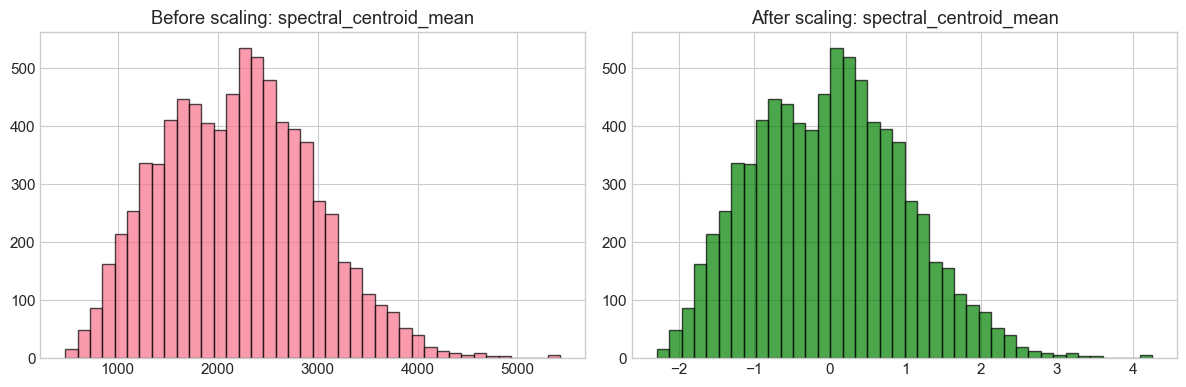

In [51]:
compare_feat = "spectral_centroid_mean"
if compare_feat in X_train_tree.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(X_train_tree[compare_feat], bins=40, edgecolor="black", alpha=0.7)
    axes[0].set_title(f"Before scaling: {compare_feat}")
    axes[1].hist(X_train_scaled[compare_feat], bins=40, edgecolor="black", alpha=0.7, color="green")
    axes[1].set_title(f"After scaling: {compare_feat}")
    plt.tight_layout()
    plt.show()


### Cell 52 — Class Distribution and Stratification Check


In [52]:
# Before split (full cleaned data)
before_split = df_clean["label"].value_counts(normalize=True).sort_index() * 100

# After split — training set (decode encoded labels for readability)
y_train_genres = label_encoder.inverse_transform(y_train)
after_train = pd.Series(y_train_genres).value_counts(normalize=True).sort_index() * 100

strat_check = pd.DataFrame({
    "before_split_pct": before_split.round(2),
    "train_set_pct": after_train.round(2),
    "difference": (after_train - before_split).abs().round(2)
})

print("Class distribution (%) before split vs. training set:")
display(strat_check)

print("\nStratified split preserves approximate class proportions across train and test sets.")


Class distribution (%) before split vs. training set:


,before_split_pct,train_set_pct,difference
blues,10.01,10.01,0.00
classical,9.99,10.00,0.01
country,9.98,9.98,0.01
disco,10.00,10.00,0.00
hiphop,9.99,9.98,0.01
jazz,10.01,10.01,0.00
metal,10.01,10.01,0.00
pop,10.01,10.01,0.00
reggae,10.01,10.01,0.00
rock,9.99,9.98,0.01



Stratified split preserves approximate class proportions across train and test sets.


## PART 12 — Save the Preprocessed Data


### Cell 53 — Save CSV Files


In [53]:
OUTPUT_DIR = r"C:\Users\Lenovo\Desktop\ci\tara1"

# Cleaned dataframe
df_clean.to_csv(f"{OUTPUT_DIR}\\features_3_sec_cleaned.csv", index=False)

# Prepared feature matrices and targets
X_train_scaled.to_csv(f"{OUTPUT_DIR}\\X_train_scaled.csv", index=False)
X_test_scaled.to_csv(f"{OUTPUT_DIR}\\X_test_scaled.csv", index=False)
X_train_tree.to_csv(f"{OUTPUT_DIR}\\X_train_tree.csv", index=False)
X_test_tree.to_csv(f"{OUTPUT_DIR}\\X_test_tree.csv", index=False)

pd.DataFrame({"label_encoded": y_train}).to_csv(f"{OUTPUT_DIR}\\y_train.csv", index=False)
pd.DataFrame({"label_encoded": y_test}).to_csv(f"{OUTPUT_DIR}\\y_test.csv", index=False)

class_mapping.to_csv(f"{OUTPUT_DIR}\\label_mapping.csv", index=False)

print("Files saved to:", OUTPUT_DIR)
print("  - features_3_sec_cleaned.csv")
print("  - X_train_scaled.csv, X_test_scaled.csv")
print("  - X_train_tree.csv, X_test_tree.csv")
print("  - y_train.csv, y_test.csv")
print("  - label_mapping.csv")


Files saved to: C:\Users\Lenovo\Desktop\ci\tara1
  - features_3_sec_cleaned.csv
  - X_train_scaled.csv, X_test_scaled.csv
  - X_train_tree.csv, X_test_tree.csv
  - y_train.csv, y_test.csv
  - label_mapping.csv


## PART 13 — Final EDA and Preprocessing Summary


### Cell 54 — Academic Summary Report


In [54]:
summary_report = f"""
================================================================================
FINAL EDA AND PREPROCESSING SUMMARY — MUSIC GENRE CLASSIFICATION
================================================================================

1. Dataset shape (original):     {df_original.shape[0]:,} rows × {df_original.shape[1]} columns
2. Dataset domain:               Audio feature extraction / Music genre classification
3. Target variable:              label (music genre)
4. Number of classes:            {df_clean['label'].nunique()}
5. Class names:                  {', '.join(sorted(df_clean['label'].unique()))}
6. Features before preprocessing: {len(feature_cols)} (excluding filename and label)
7. Features after preprocessing:  {X_model.shape[1]} (filename and constant length dropped)
8. Missing values:               {df_original.isnull().sum().sum()} (none found)
9. Duplicate rows:               {df_original.duplicated().sum()} removed → {len(df_original) - len(df_clean)}
10. Constant columns:            length (unique values = {df_clean['length'].nunique()}) — dropped
11. Class balance:               Approximately balanced (~1000 samples per genre)
12. Distribution findings:       Audio features show varying skewness; MFCC and spectral
                                 features differ across genres (see ANOVA/Kruskal-Wallis results)
13. Correlation / multicollinearity: Some MFCC mean/var pairs and spectral features are highly
                                 correlated; tree models less affected than linear models
14. Outliers:                    Present under IQR/Z-score rules; retained as likely valid variation
15. Preprocessing applied:
    - Duplicate removal (if any) → df_clean
    - Dropped filename, constant length
    - LabelEncoder on target
    - Stratified train/test split (80/20, random_state=42)
    - StandardScaler fit on train only
16. Final datasets:
    - Scaled:   X_train_scaled, X_test_scaled, y_train, y_test
    - Unscaled: X_train_tree, X_test_tree, y_train, y_test
17. Target encoding:              See label_mapping.csv and label_encoder
18. Two versions rationale:
    - Scaled:   For Logistic Regression, Neural Networks, SVM, k-NN
    - Unscaled: For Random Forest and tree-based models (scale-invariant splits)

================================================================================
Next notebooks: Linear Classifier | Random Forest | Neural Network
================================================================================
"""

print(summary_report)



FINAL EDA AND PREPROCESSING SUMMARY — MUSIC GENRE CLASSIFICATION

1. Dataset shape (original):     9,990 rows × 60 columns
2. Dataset domain:               Audio feature extraction / Music genre classification
3. Target variable:              label (music genre)
4. Number of classes:            10
5. Class names:                  blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock
6. Features before preprocessing: 58 (excluding filename and label)
7. Features after preprocessing:  57 (filename and constant length dropped)
8. Missing values:               0 (none found)
9. Duplicate rows:               0 removed → 0
10. Constant columns:            length (unique values = 1) — dropped
11. Class balance:               Approximately balanced (~1000 samples per genre)
12. Distribution findings:       Audio features show varying skewness; MFCC and spectral
                                 features differ across genres (see ANOVA/Kruskal-Wallis results)
13. Correlation 

---

## End of Notebook

This notebook completed exploratory data analysis and preprocessing for the **features_3_sec** music genre classification dataset. No models were trained. Proceed to modeling notebooks using the saved CSV files and in-memory variables (`X_train_scaled`, `X_test_scaled`, `X_train_tree`, `X_test_tree`, `y_train`, `y_test`, `label_encoder`, `class_mapping`).
